# FarmTech Solutions – Previsão de rendimento de safra e tendências de produtividade

**Curso:** Tecnologia em Inteligência Artificial – FIAP
**Atividade:** PBL Fase 5 – Machine Learning na cabeça (Entrega 1)
**Aluno:** Ronaldo Keity Sieg Nishime – RM571759

---

## Sumário

1. Contexto e objetivos
2. Configuração do ambiente e carga dos dados
3. Análise exploratória dos dados (EDA)
4. Tendências e outliers com aprendizado não supervisionado
5. Modelagem preditiva com regressão supervisionada
6. Conclusões, pontos fortes e limitações
7. Referências

## 1. Contexto e objetivos

A **FarmTech Solutions** presta serviços de Inteligência Artificial para uma fazenda de médio porte (200 hectares, o equivalente a cerca de 210 campos de futebol oficiais) que produz várias culturas. A fazenda disponibilizou uma base histórica que relaciona **condições climáticas** (precipitação, umidade específica, umidade relativa e temperatura, todas medidas a 2 metros do solo) com o **rendimento** de cada cultura.

O trabalho segue a metodologia **CRISP-DM** (entendimento do negócio → entendimento dos dados → preparação → modelagem → avaliação) e tem três metas, alinhadas ao enunciado:

| # | Meta | Técnica |
|---|------|---------|
| 1 | Familiarizar-se com os dados | Análise exploratória (estatísticas descritivas, distribuições, correlações) |
| 2 | Encontrar **tendências de rendimento** e identificar **cenários discrepantes (outliers)** | Clusterização (K-Means, hierárquica) e detecção de anomalias (IQR, distância ao centróide, Isolation Forest) – Fase 5, Cap. 10 |
| 3 | Construir **cinco modelos preditivos** com algoritmos diferentes para prever o rendimento | Regressão supervisionada (Linear, Árvore de Decisão, Random Forest, Gradient Boosting e SVR) com validação cruzada, ajuste de hiperparâmetros e métricas de regressão – Fase 4, Cap. 13 |

### Dicionário de dados (`crop_yield.csv`)

| Coluna original | Nome usado no notebook | Descrição | Unidade |
|-----------------|------------------------|-----------|---------|
| Crop | `cultura` | Nome da cultura cujo rendimento está sendo medido | – |
| Precipitation (mm day-1) | `precipitacao` | Chuva média por dia | mm/dia |
| Specific Humidity at 2 Meters (g/kg) | `umidade_especifica` | Vapor de água por quilograma de ar seco, a 2 m do solo | g/kg |
| Relative Humidity at 2 Meters (%) | `umidade_relativa` | Vapor de água em relação ao máximo possível na temperatura e pressão atuais, a 2 m do solo | % |
| Temperature at 2 Meters (C) | `temperatura` | Temperatura do ar a 2 m do solo | ºC |
| Yield | `rendimento` | Rendimento da safra (**variável-alvo**) | ver observação na EDA |

## 2. Configuração do ambiente e carga dos dados

Bibliotecas utilizadas: `pandas`/`numpy` (manipulação de dados), `matplotlib`/`seaborn` (visualização), `scipy` (clusterização hierárquica) e `scikit-learn` (pré-processamento, clusterização, detecção de anomalias, modelos de regressão e métricas). A semente aleatória é fixada para garantir **reprodutibilidade** de todos os resultados.

In [1]:
# === Configuração do ambiente ===
import warnings                                   # controle de avisos, para manter a saída limpa
from pathlib import Path                          # manipulação de caminhos de forma portátil

import numpy as np                                # computação numérica (vetores e matrizes)
import pandas as pd                               # manipulação e análise de dados tabulares
import matplotlib.pyplot as plt                   # geração de gráficos
import seaborn as sns                             # gráficos estatísticos de alto nível
import sklearn                                    # biblioteca de machine learning (versão exibida abaixo)

warnings.filterwarnings("ignore")                 # silencia avisos não críticos (ex.: FutureWarning)
RANDOM_STATE = 42                                 # semente fixa para reprodutibilidade
np.random.seed(RANDOM_STATE)                      # aplica a semente ao gerador do NumPy

sns.set_theme(style="whitegrid")                  # tema visual padrão dos gráficos
plt.rcParams["figure.dpi"] = 100                  # resolução das figuras exibidas no notebook
pd.set_option("display.max_columns", 50)          # exibe todas as colunas nas tabelas
pd.set_option("display.float_format", "{:.2f}".format)  # duas casas decimais nas tabelas

ASSETS = Path("assets")                           # pasta onde as figuras principais são salvas (uso no README)
ASSETS.mkdir(exist_ok=True)                       # cria a pasta caso não exista

print(f"pandas {pd.__version__} | numpy {np.__version__} | scikit-learn {sklearn.__version__} | seaborn {sns.__version__}")

pandas 2.3.3 | numpy 2.3.4 | scikit-learn 1.9.0 | seaborn 0.13.2


In [2]:
# === Carga da base de dados ===
CANDIDATOS = ["crop_yield.csv", "dados/crop_yield.csv", "../crop_yield.csv"]   # locais possíveis do arquivo
caminho = next((c for c in CANDIDATOS if Path(c).exists()), None)               # primeiro caminho que existir
if caminho is None:                                                              # arquivo não encontrado
    raise FileNotFoundError("Arquivo crop_yield.csv não encontrado: coloque-o na mesma pasta do notebook.")

df_raw = pd.read_csv(caminho)                                                    # lê o CSV em um DataFrame
print(f"Arquivo carregado: {caminho} | {df_raw.shape[0]} linhas x {df_raw.shape[1]} colunas")
df_raw.head()                                                                    # 5 primeiras linhas

Arquivo carregado: crop_yield.csv | 156 linhas x 6 colunas


,Crop,Precipitation (mm day-1),Specific Humidity at 2 Meters (g/kg),Relative Humidity at 2 Meters (%),Temperature at 2 Meters (C),Yield
0,"Cocoa, beans",2248.92,17.72,83.40,26.01,11560
1,"Cocoa, beans",1938.42,17.54,82.11,26.11,11253
2,"Cocoa, beans",2301.54,17.81,82.79,26.24,9456
3,"Cocoa, beans",2592.35,17.61,85.07,25.56,9321
4,"Cocoa, beans",2344.72,17.61,84.12,25.76,8800


In [3]:
# === Padronização dos nomes das colunas ===
# Cada coluna original recebe um nome curto (sem espaços e unidades), o que simplifica o código.
MAPA_COLUNAS = {}                                                      # {nome_original: nome_padronizado}
for col in df_raw.columns:                                             # percorre as colunas originais
    c = col.lower()                                                    # versão minúscula para comparação
    if "crop" in c:          MAPA_COLUNAS[col] = "cultura"             # cultura agrícola (categórica)
    elif "precip" in c:      MAPA_COLUNAS[col] = "precipitacao"        # chuva (mm/dia)
    elif "specific" in c:    MAPA_COLUNAS[col] = "umidade_especifica"  # umidade específica (g/kg)
    elif "relative" in c:    MAPA_COLUNAS[col] = "umidade_relativa"    # umidade relativa (%)
    elif "temp" in c:        MAPA_COLUNAS[col] = "temperatura"         # temperatura (ºC)
    elif "yield" in c:       MAPA_COLUNAS[col] = "rendimento"          # rendimento (alvo)

df = df_raw.rename(columns=MAPA_COLUNAS).copy()                        # aplica o mapeamento em uma cópia
df["cultura"] = df["cultura"].astype(str).str.strip()                  # garante texto limpo na cultura

NUMERICAS = ["precipitacao", "umidade_especifica", "umidade_relativa", "temperatura"]  # variáveis climáticas
ALVO = "rendimento"                                                                    # variável-alvo
CULTURAS = sorted(df["cultura"].unique())                                              # lista ordenada de culturas

pd.DataFrame({"coluna_original": MAPA_COLUNAS.keys(), "coluna_padronizada": MAPA_COLUNAS.values()})

,coluna_original,coluna_padronizada
0,Crop,cultura
1,Precipitation (mm day-1),precipitacao
2,Specific Humidity at 2 Meters (g/kg),umidade_especifica
3,Relative Humidity at 2 Meters (%),umidade_relativa
4,Temperature at 2 Meters (C),temperatura
5,Yield,rendimento


## 3. Análise exploratória dos dados (EDA)

### 3.1 Estrutura e qualidade dos dados

Antes de qualquer modelagem verificamos tipos de dados, valores ausentes, registros duplicados e o balanceamento entre culturas.

In [4]:
# === Estrutura e qualidade dos dados ===
df.info()                                                             # tipos de dados e contagem de não nulos
print("\nValores ausentes por coluna:")
print(df.isna().sum().to_string())                                    # valores faltantes em cada coluna
print(f"\nLinhas duplicadas: {df.duplicated().sum()}")                # registros repetidos
print("\nRegistros por cultura:")
print(df["cultura"].value_counts().to_string())                       # balanceamento entre culturas

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 156 entries, 0 to 155
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   cultura             156 non-null    object 
 1   precipitacao        156 non-null    float64
 2   umidade_especifica  156 non-null    float64
 3   umidade_relativa    156 non-null    float64
 4   temperatura         156 non-null    float64
 5   rendimento          156 non-null    int64  
dtypes: float64(4), int64(1), object(1)
memory usage: 7.4+ KB

Valores ausentes por coluna:
cultura               0
precipitacao          0
umidade_especifica    0
umidade_relativa      0
temperatura           0
rendimento            0

Linhas duplicadas: 0

Registros por cultura:
cultura
Cocoa, beans       39
Oil palm fruit     39
Rice, paddy        39
Rubber, natural    39


In [5]:
# === Estatísticas descritivas ===
display(df[NUMERICAS + [ALVO]].describe().T)                          # resumo estatístico das variáveis numéricas

resumo_cultura = (df.groupby("cultura")[ALVO]                          # agrupa o rendimento por cultura
                    .agg(n="count", media="mean", mediana="median",
                         desvio="std", minimo="min", maximo="max"))    # estatísticas do rendimento
resumo_cultura["cv_%"] = 100 * resumo_cultura["desvio"] / resumo_cultura["media"]  # coeficiente de variação
resumo_cultura                                                        # tabela por cultura

,count,mean,std,min,25%,50%,75%,max
precipitacao,156.00,2486.50,289.46,1934.62,2302.99,2424.55,2718.08,3085.79
umidade_especifica,156.00,18.20,0.29,17.54,18.03,18.27,18.40,18.70
umidade_relativa,156.00,84.74,1.00,82.11,84.12,84.85,85.51,86.10
temperatura,156.00,26.18,0.26,25.56,26.02,26.13,26.30,26.81
rendimento,156.00,56153.10,70421.96,5249.00,8327.75,18871.00,67518.75,203399.00


,n,media,mediana,desvio,minimo,maximo,cv_%
cultura,,,,,,,
"Cocoa, beans",39,8883.13,8848.00,1745.03,5765,13056,19.64
Oil palm fruit,39,175804.69,175629.00,14919.87,142425,203399,8.49
"Rice, paddy",39,32099.67,31101.00,4789.95,24686,42550,14.92
"Rubber, natural",39,7824.90,7817.00,1600.26,5249,10285,20.45


In [6]:
# === As condições climáticas se repetem entre as culturas? ===
# Conta quantos perfis climáticos distintos existem em relação ao número de linhas da base.
perfis_distintos = df[NUMERICAS].drop_duplicates().shape[0]          # nº de combinações climáticas distintas
repeticao = len(df) / perfis_distintos                                # quantas vezes cada perfil aparece
print(f"Perfis climáticos distintos: {perfis_distintos} de {len(df)} linhas "
      f"(cada perfil aparece em média {repeticao:.1f} vezes; a base tem {len(CULTURAS)} culturas).")

Perfis climáticos distintos: 39 de 156 linhas (cada perfil aparece em média 4.0 vezes; a base tem 4 culturas).


### 3.2 Distribuições

Histogramas das variáveis numéricas e a distribuição do rendimento por cultura. O rendimento é apresentado também por cultura, pois as culturas têm escalas de produtividade muito diferentes entre si.

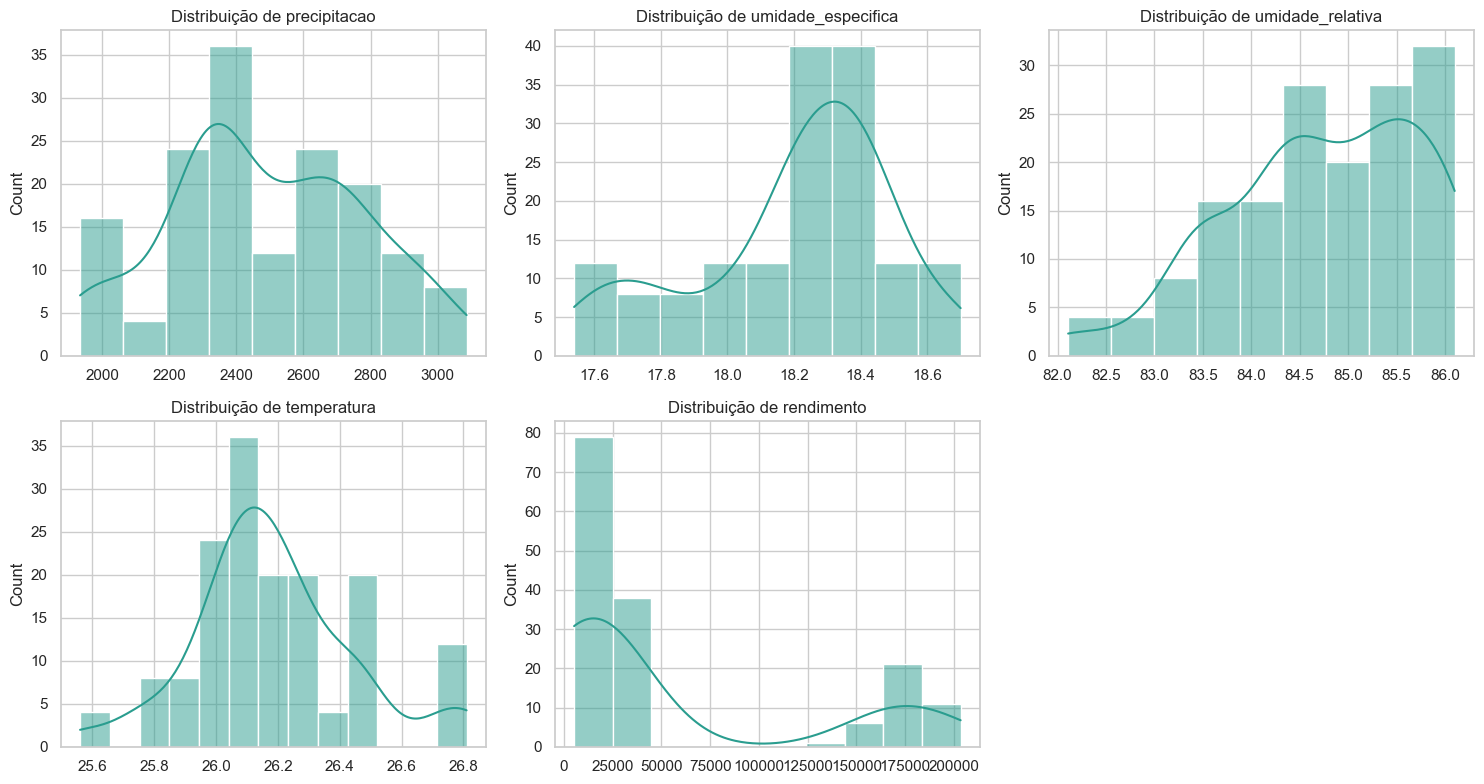

In [7]:
# === Distribuição das variáveis numéricas ===
fig, axes = plt.subplots(2, 3, figsize=(15, 8))                      # grade 2x3 de gráficos
axes = axes.ravel()                                                  # matriz de eixos -> lista
for ax, col in zip(axes, NUMERICAS + [ALVO]):                        # um histograma por variável
    sns.histplot(df[col], kde=True, ax=ax, color="#2a9d8f")          # histograma com curva de densidade
    ax.set_title(f"Distribuição de {col}")                           # título do subgráfico
    ax.set_xlabel("")                                                # remove rótulo redundante
axes[-1].axis("off")                                                 # desliga o 6º eixo (não utilizado)
plt.tight_layout()                                                   # ajusta o espaçamento
plt.show()

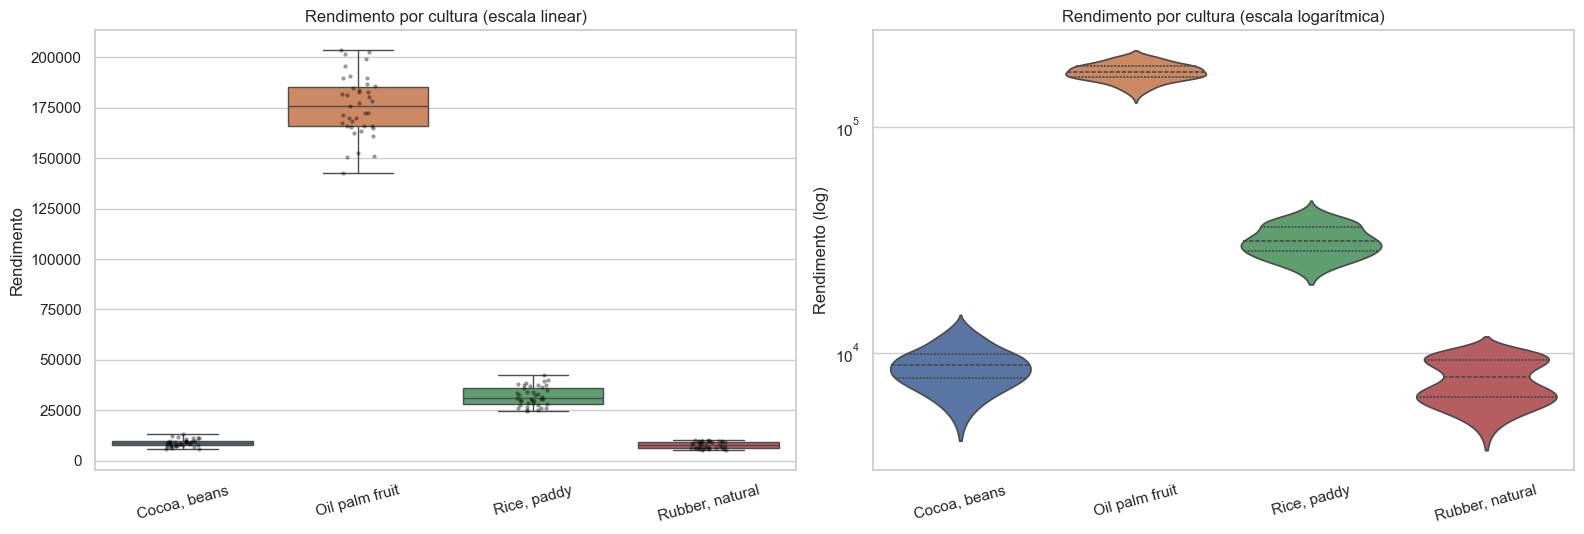

In [8]:
# === Rendimento por cultura ===
fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))                    # dois gráficos lado a lado
sns.boxplot(data=df, x="cultura", y=ALVO, hue="cultura", legend=False, ax=axes[0])       # boxplot por cultura
sns.stripplot(data=df, x="cultura", y=ALVO, color="black", alpha=0.4, size=3, ax=axes[0]) # pontos individuais
axes[0].set(title="Rendimento por cultura (escala linear)", xlabel="", ylabel="Rendimento")
axes[0].tick_params(axis="x", rotation=15)                           # inclina os rótulos das culturas

sns.violinplot(data=df, x="cultura", y=ALVO, hue="cultura", legend=False, inner="quart", ax=axes[1])  # violino
axes[1].set_yscale("log")                                            # escala log para comparar culturas de escalas distintas
axes[1].set(title="Rendimento por cultura (escala logarítmica)", xlabel="", ylabel="Rendimento (log)")
axes[1].tick_params(axis="x", rotation=15)
plt.tight_layout()
fig.savefig(ASSETS / "eda_rendimento_por_cultura.png", dpi=120, bbox_inches="tight")  # salva para o README
plt.show()

### 3.3 Relações entre clima e rendimento

Como as culturas têm escalas de rendimento muito diferentes, a correlação calculada na base completa mistura o efeito da **cultura** com o efeito do **clima**. Por isso, além da matriz de correlação global, calculamos a correlação clima × rendimento **dentro de cada cultura**, que é a informação relevante para o agrônomo.

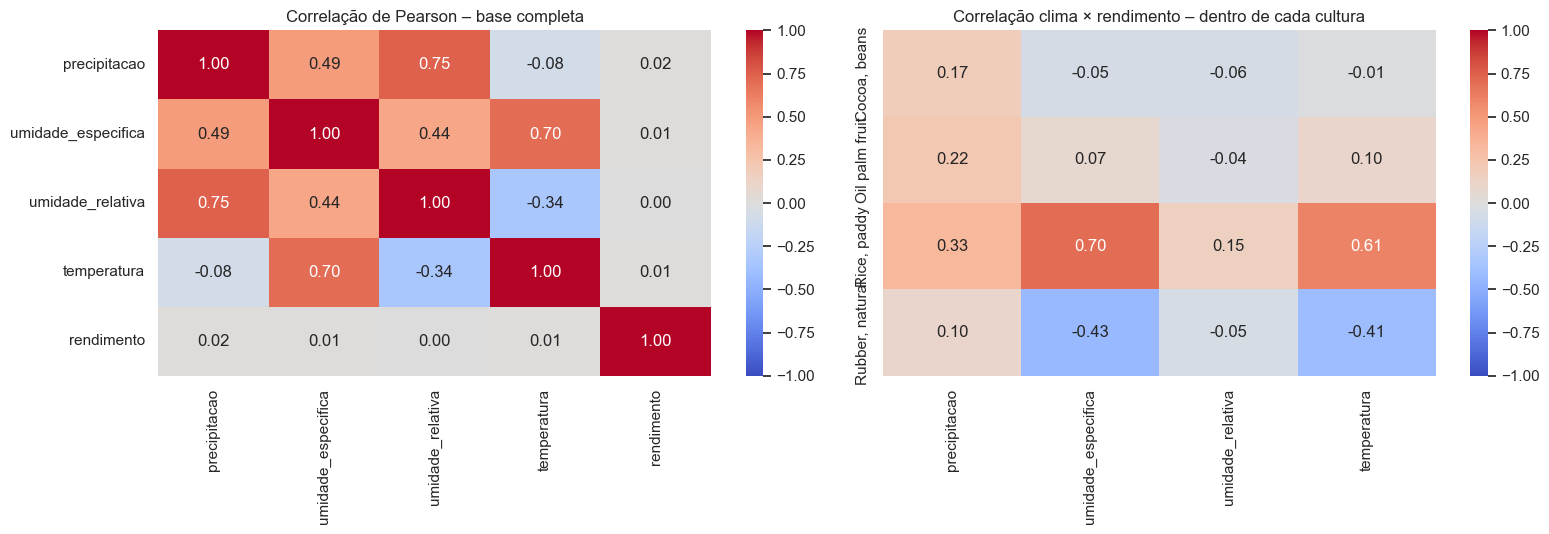

In [9]:
# === Correlações: global e dentro de cada cultura ===
fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))
corr_global = df[NUMERICAS + [ALVO]].corr()                          # correlação de Pearson na base completa
sns.heatmap(corr_global, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, ax=axes[0])
axes[0].set_title("Correlação de Pearson – base completa")

corr_intra = (df.groupby("cultura")[NUMERICAS + [ALVO]].corr()[ALVO]  # correlação com o rendimento, por cultura
                .unstack()[NUMERICAS])                                 # tabela cultura x variável climática
sns.heatmap(corr_intra, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, ax=axes[1])
axes[1].set_title("Correlação clima × rendimento – dentro de cada cultura")
axes[1].set_ylabel("")
plt.tight_layout()
plt.show()

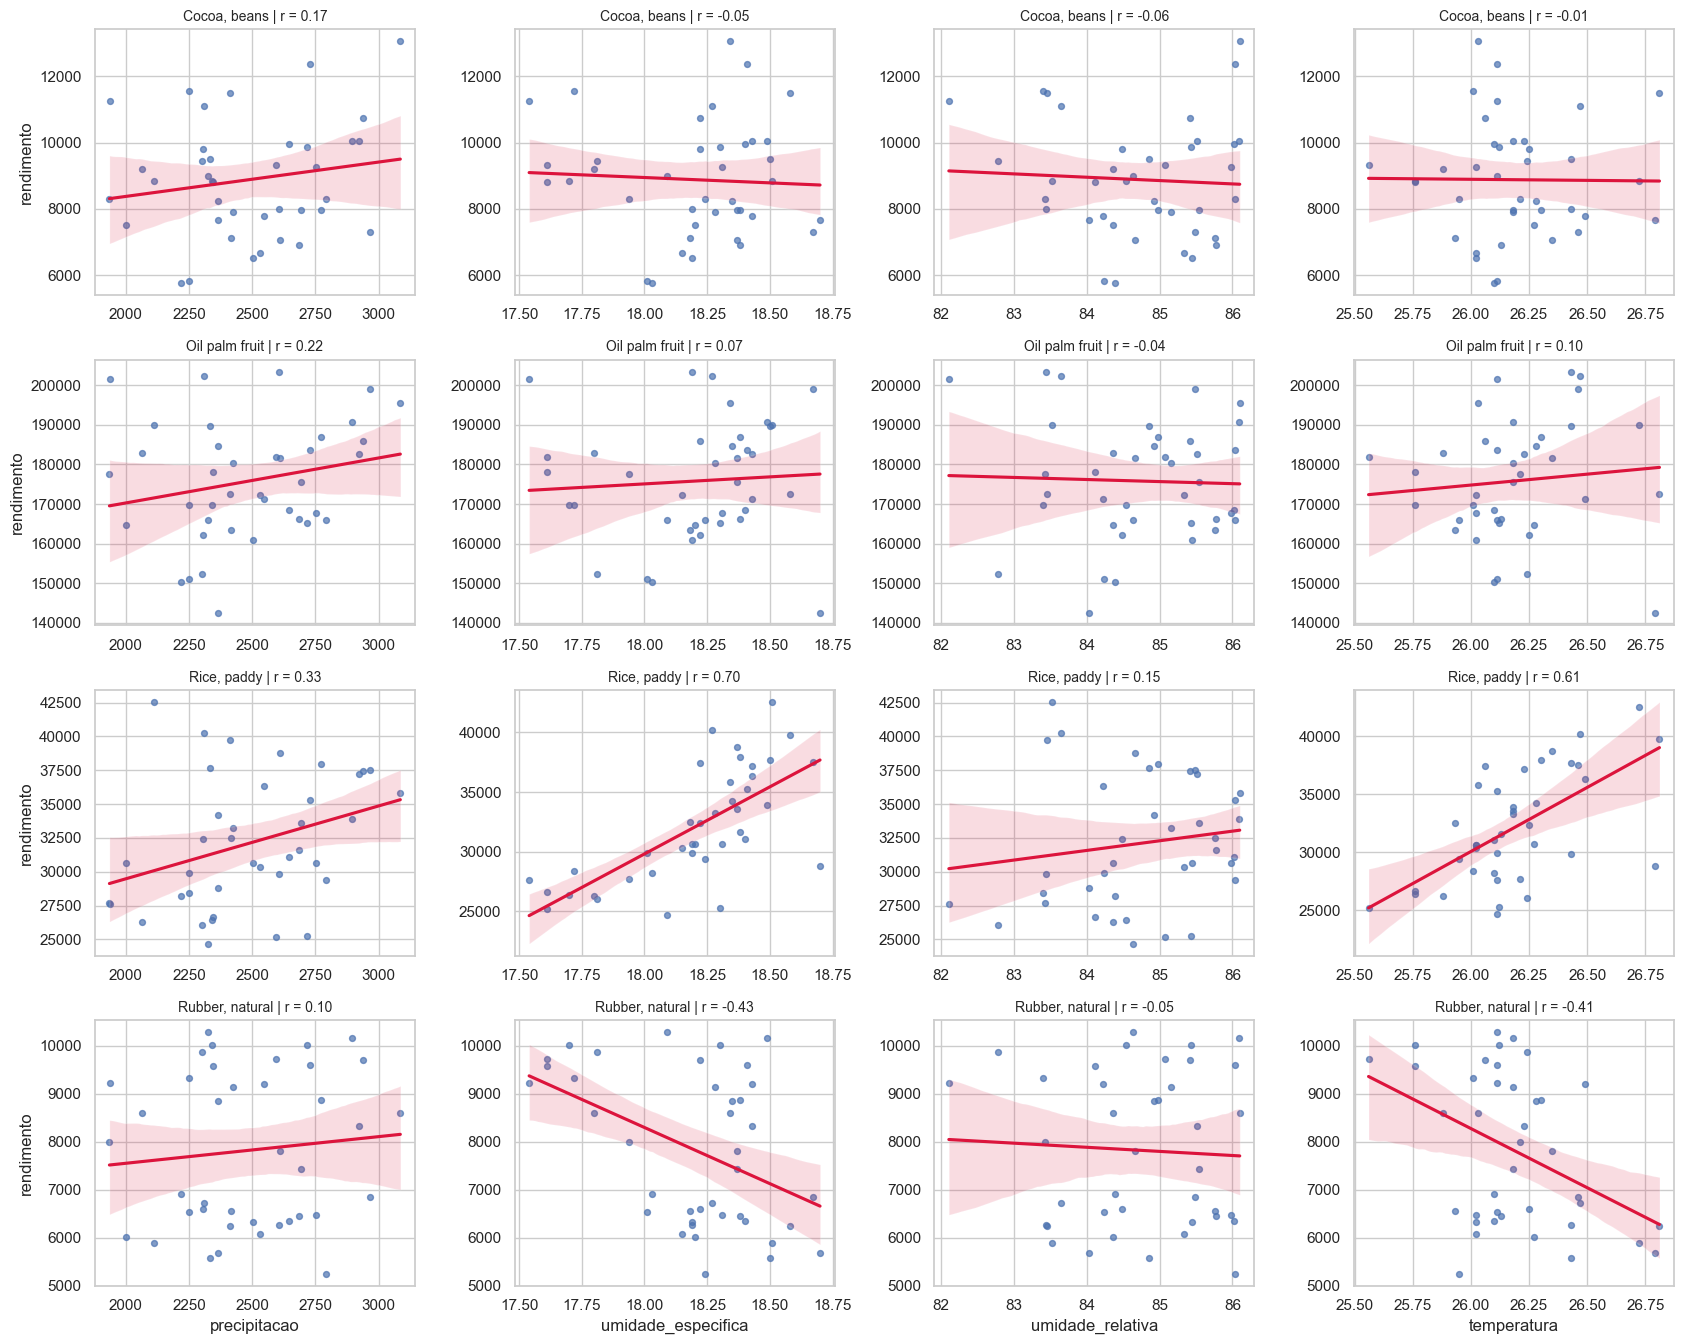

In [10]:
# === Dispersão clima x rendimento, por cultura, com reta de tendência ===
fig, axes = plt.subplots(len(CULTURAS), len(NUMERICAS), figsize=(17, 3.4 * len(CULTURAS)))
axes = np.atleast_2d(axes)                                           # garante matriz 2D mesmo com 1 cultura
for i, cult in enumerate(CULTURAS):                                  # uma linha de gráficos por cultura
    sub = df[df["cultura"] == cult]                                  # dados da cultura
    for j, col in enumerate(NUMERICAS):                              # uma coluna por variável climática
        ax = axes[i, j]
        sns.regplot(data=sub, x=col, y=ALVO, ax=ax,                  # dispersão + reta de regressão simples
                    scatter_kws={"s": 18, "alpha": 0.7}, line_kws={"color": "crimson"})
        r = sub[col].corr(sub[ALVO])                                 # correlação de Pearson na cultura
        ax.set_title(f"{cult} | r = {r:.2f}", fontsize=10)
        ax.set_xlabel(col if i == len(CULTURAS) - 1 else "")         # rótulo só na última linha
        ax.set_ylabel(ALVO if j == 0 else "")                        # rótulo só na primeira coluna
plt.tight_layout()
plt.show()

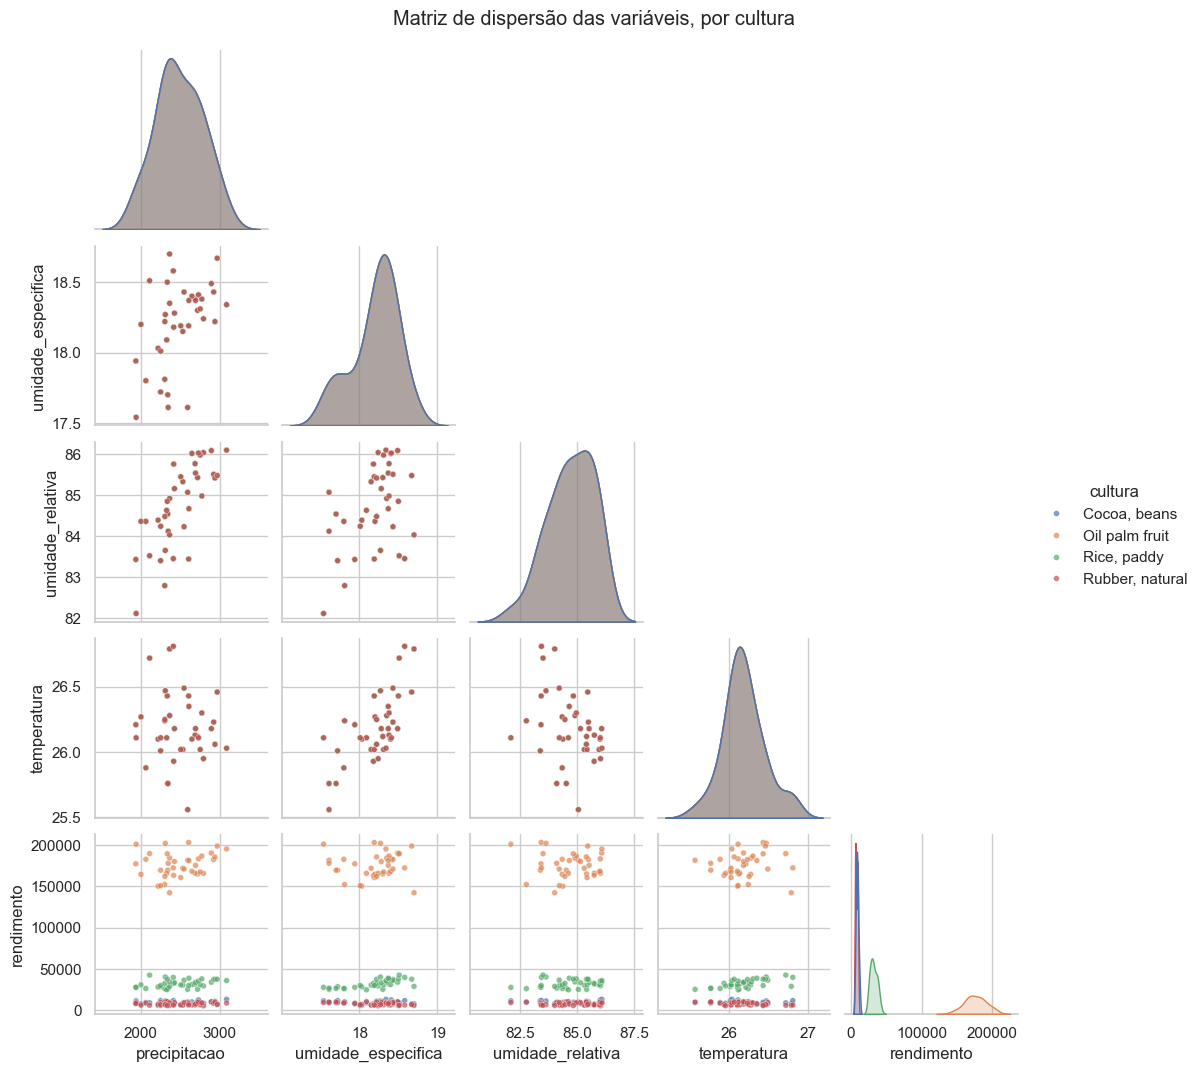

In [11]:
# === Matriz de dispersão colorida por cultura ===
g = sns.pairplot(df, vars=NUMERICAS + [ALVO], hue="cultura", corner=True,
                 plot_kws={"s": 18, "alpha": 0.7}, height=2.1)      # pares de variáveis, cor = cultura
g.figure.suptitle("Matriz de dispersão das variáveis, por cultura", y=1.02)
plt.show()

### 3.4 Achados da análise exploratória

- **Base pequena e limpa.** 156 registros, quatro culturas (cacau, dendê/*oil palm*, arroz e borracha natural) com 39 registros cada, sem valores ausentes nem duplicados.
- **Escala do rendimento.** A ordem de grandeza (dendê ≈ 175.800; arroz ≈ 32.100; cacau ≈ 8.900; borracha ≈ 7.800) é compatível com **hg/ha** (hectograma por hectare, unidade padrão da FAOSTAT), e não com t/ha como descrito no enunciado: dividindo por 10.000 obtêm-se valores agronômicos plausíveis (≈ 17,6 t/ha de cachos de dendê, ≈ 3,2 t/ha de arroz, ≈ 0,9 t/ha de cacau e ≈ 0,8 t/ha de borracha). Como é apenas um fator de escala, os valores originais foram mantidos. Da mesma forma, a precipitação (1.935 a 3.086) corresponde ao acumulado anual em mm, apesar do rótulo "mm day-1".
- **O clima é o mesmo para todas as culturas.** Existem apenas 39 perfis climáticos distintos, cada um repetido exatamente quatro vezes: a base é uma série de 39 anos de uma mesma região de clima equatorial (temperatura entre 25,6 e 26,8 ºC, umidade relativa entre 82 e 86%, umidade específica entre 17,5 e 18,7 g/kg) cruzada com quatro culturas. Consequência direta: as variáveis climáticas **não distinguem** as culturas; quem explica a diferença de rendimento entre linhas é a cultura.
- **Variabilidade.** Entre culturas o rendimento varia mais de 20 vezes; dentro de cada cultura a variação é pequena (coeficiente de variação de 8,5% no dendê, 14,9% no arroz, 19,6% no cacau e 20,5% na borracha), assim como a variação do clima entre anos (desvio-padrão de apenas 0,26 ºC na temperatura).
- **Correlações.** Na base completa, as correlações clima × rendimento são próximas de zero, porque o efeito da cultura domina. Dentro das culturas o quadro muda: o arroz tem correlação positiva com umidade específica (r = 0,70) e temperatura (r = 0,61); a borracha, negativa com temperatura (r = −0,41) e umidade específica (r = −0,43); dendê e cacau praticamente não se correlacionam com o clima (|r| ≤ 0,22). Isso já antecipa que o poder preditivo do clima será modesto e diferente para cada cultura.

## 4. Tendências e outliers com aprendizado não supervisionado

Nesta seção aplicamos o conteúdo do Cap. 10 da Fase 5 (*Machine Learning Sem Supervisão*) com dois objetivos:

1. **Tendências de rendimento** – descobrir agrupamentos naturais nos dados (K-Means e clusterização hierárquica) e, dentro de cada cultura, identificar **regimes de produtividade** (baixo, médio e alto) associados a diferentes condições climáticas.
2. **Cenários discrepantes** – identificar outliers combinando três métodos complementares: regra do IQR (univariado, por cultura), distância ao centróide do cluster (baseado na clusterização) e Isolation Forest (multivariado).

Todas as variáveis são **padronizadas** (média 0, desvio 1) antes da clusterização, pois K-Means e métodos baseados em distância são sensíveis à escala.

### 4.1 Escolha do número de clusters (K-Means)

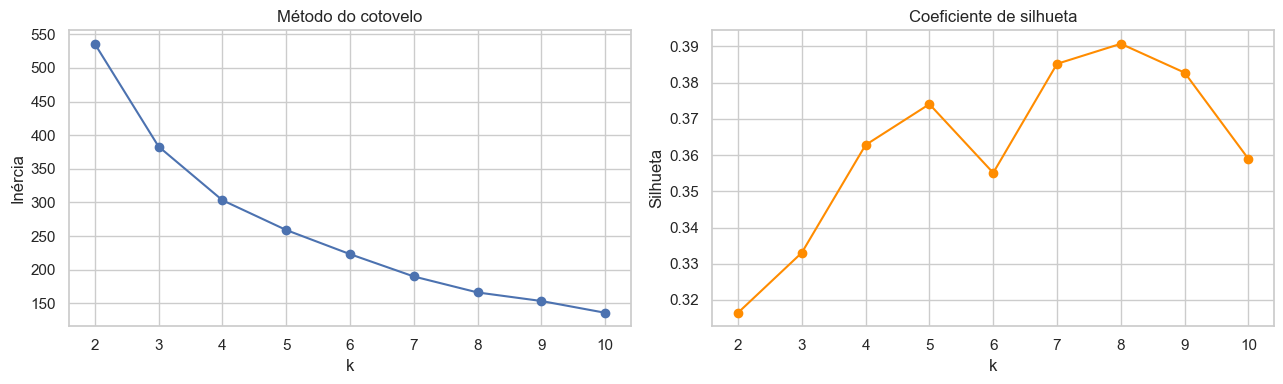

k sugerido pela silhueta: 8 (silhueta = 0.391)


In [12]:
# === Preparação e escolha de k para o K-Means ===
from sklearn.preprocessing import StandardScaler                    # padronização das variáveis
from sklearn.cluster import KMeans                                  # algoritmo K-Means
from sklearn.metrics import silhouette_score                        # métrica de qualidade dos clusters
from sklearn.decomposition import PCA                               # redução de dimensionalidade para visualização

VARS_CLUSTER = NUMERICAS + [ALVO]                                    # variáveis usadas na clusterização
X_cl = StandardScaler().fit_transform(df[VARS_CLUSTER])              # matriz padronizada

ks = range(2, 11)                                                    # valores de k avaliados
inercias, silhuetas = [], []                                         # métricas para cada k
for k in ks:                                                         # treina um K-Means por valor de k
    km = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE).fit(X_cl)
    inercias.append(km.inertia_)                                     # soma das distâncias intra-cluster (cotovelo)
    silhuetas.append(silhouette_score(X_cl, km.labels_))             # coesão/separação (quanto maior, melhor)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(ks, inercias, marker="o");                  axes[0].set(title="Método do cotovelo", xlabel="k", ylabel="Inércia")
axes[1].plot(ks, silhuetas, marker="o", color="darkorange"); axes[1].set(title="Coeficiente de silhueta", xlabel="k", ylabel="Silhueta")
plt.tight_layout(); plt.show()

k_otimo = ks[int(np.argmax(silhuetas))]                              # k com maior silhueta
print(f"k sugerido pela silhueta: {k_otimo} (silhueta = {max(silhuetas):.3f})")

### 4.2 Clusters encontrados e relação com as culturas

Comparamos os clusters do K-Means com as culturas (tabela de contingência), descrevemos o perfil médio de cada cluster e visualizamos os grupos em duas dimensões usando PCA. A clusterização hierárquica (método de Ward) é usada como segunda opinião sobre a estrutura de grupos.

Tabela de contingência cultura x cluster:


cluster,0,1,2,3,4,5,6,7
cultura,,,,,,,,
"Cocoa, beans",0,8,10,4,0,0,13,4
Oil palm fruit,17,0,0,0,11,11,0,0
"Rice, paddy",0,8,10,4,0,0,13,4
"Rubber, natural",0,8,10,4,0,0,13,4


Perfil médio (valores originais) de cada cluster:


,precipitacao,umidade_especifica,umidade_relativa,temperatura,rendimento,n
cluster,,,,,,
0,2733.52,18.34,85.65,26.12,177074.18,17
1,2410.39,18.44,83.98,26.56,17456.38,24
2,2333.41,18.17,84.87,26.13,15149.97,30
3,2105.88,17.75,82.93,26.14,15562.08,12
4,2232.22,17.81,83.92,25.99,171039.91,11
5,2359.02,18.39,84.15,26.48,178607.55,11
6,2814.98,18.38,85.72,26.14,17044.28,39
7,2334.49,17.68,84.52,25.74,14881.33,12


Variância explicada pelas 2 componentes: 74.8%


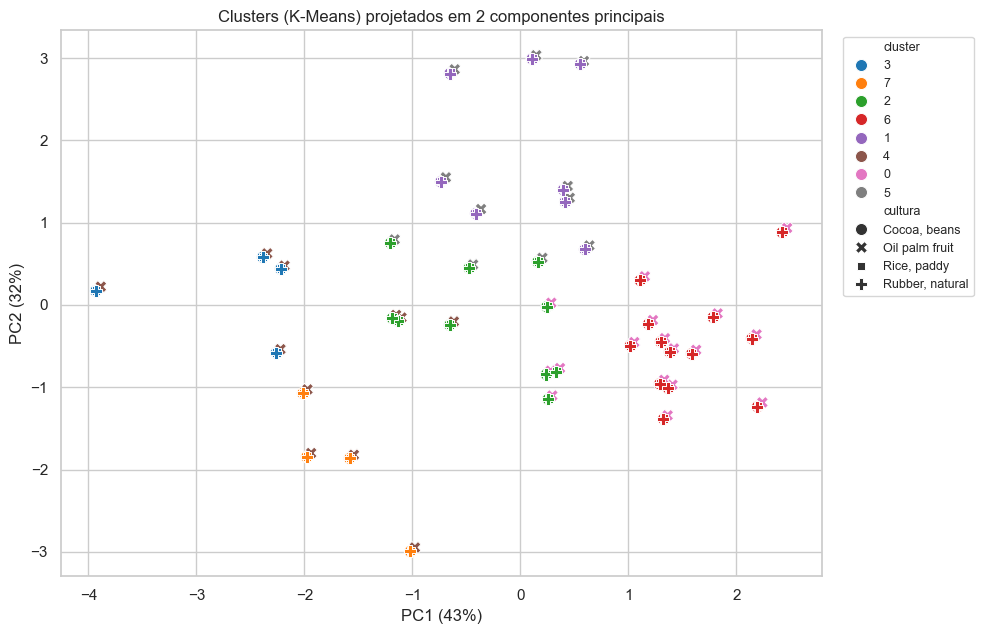

In [13]:
# === K-Means final, perfil dos clusters e projeção PCA ===
kmeans = KMeans(n_clusters=k_otimo, n_init=10, random_state=RANDOM_STATE).fit(X_cl)  # modelo final
df["cluster"] = kmeans.labels_                                       # rótulo de cluster de cada linha

print("Tabela de contingência cultura x cluster:")
display(pd.crosstab(df["cultura"], df["cluster"]))                   # quantas linhas de cada cultura caem em cada cluster

print("Perfil médio (valores originais) de cada cluster:")
perfil_clusters = df.groupby("cluster")[VARS_CLUSTER].mean()         # médias por cluster
perfil_clusters["n"] = df["cluster"].value_counts().sort_index()     # tamanho de cada cluster
display(perfil_clusters)

pca = PCA(n_components=2, random_state=RANDOM_STATE)                 # projeção em 2 componentes principais
comp = pca.fit_transform(X_cl)                                       # coordenadas de cada linha no plano PCA
df["pc1"], df["pc2"] = comp[:, 0], comp[:, 1]                        # guarda as coordenadas para gráficos
print(f"Variância explicada pelas 2 componentes: {pca.explained_variance_ratio_.sum():.1%}")

fig, ax = plt.subplots(figsize=(10, 6.5))
sns.scatterplot(data=df, x="pc1", y="pc2", hue=df["cluster"].astype(str), style="cultura",
                s=75, palette="tab10", ax=ax)                        # cor = cluster, marcador = cultura
ax.set(title="Clusters (K-Means) projetados em 2 componentes principais",
       xlabel=f"PC1 ({pca.explained_variance_ratio_[0]:.0%})", ylabel=f"PC2 ({pca.explained_variance_ratio_[1]:.0%})")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=9)
plt.tight_layout()
fig.savefig(ASSETS / "clusters_pca.png", dpi=120, bbox_inches="tight")
plt.show()

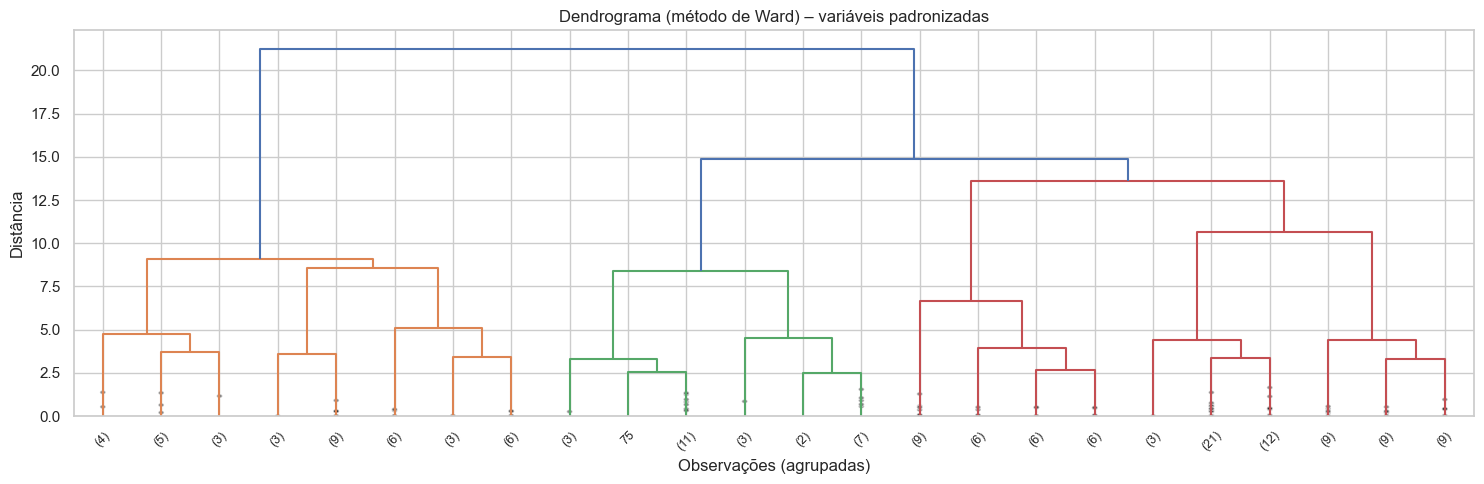

In [14]:
# === Clusterização hierárquica (Ward) – dendrograma ===
from scipy.cluster.hierarchy import linkage, dendrogram              # funções de clusterização hierárquica

Z = linkage(X_cl, method="ward")                                     # matriz de ligação (minimiza variância intra-cluster)
fig, ax = plt.subplots(figsize=(15, 5))
dendrogram(Z, truncate_mode="lastp", p=24, leaf_font_size=9,
           show_contracted=True, ax=ax)                              # exibe os 24 últimos agrupamentos
ax.set(title="Dendrograma (método de Ward) – variáveis padronizadas",
       xlabel="Observações (agrupadas)", ylabel="Distância")
plt.tight_layout(); plt.show()

### 4.3 Regimes de produtividade dentro de cada cultura

Para revelar **tendências** úteis à fazenda, repetimos a clusterização **dentro de cada cultura** (clima + rendimento padronizados por cultura). Os clusters são nomeados pelo rendimento médio – **baixo**, **médio** e **alto** – e, para cada regime, calculamos as condições climáticas médias. A diferença entre o regime *alto* e o regime *baixo* indica quais condições acompanham as melhores safras. Nesta etapa também calculamos a distância de cada observação ao centróide do seu regime, usada na detecção de outliers, e treinamos um Isolation Forest por cultura.

In [15]:
# === Clusterização por cultura: regimes de produtividade e sinais de outlier ===
from sklearn.ensemble import IsolationForest                         # detector multivariado de anomalias

K_INTRA = 3                                                          # nº de regimes por cultura
NOMES_REGIME = ["baixo", "medio", "alto"]                            # nomes ordenados pelo rendimento médio
df["regime"] = ""                                                    # regime de produtividade
df["dist_centroide"] = np.nan                                        # distância ao centróide do próprio regime
df["out_dist"] = False                                               # outlier pela distância ao centróide
df["out_iso"] = False                                                # outlier pelo Isolation Forest

for cult in CULTURAS:                                                # processa uma cultura por vez
    idx = df.index[df["cultura"] == cult]                            # índices das linhas da cultura
    Xc = StandardScaler().fit_transform(df.loc[idx, VARS_CLUSTER])   # padroniza dentro da cultura
    kmc = KMeans(n_clusters=K_INTRA, n_init=10, random_state=RANDOM_STATE).fit(Xc)  # K-Means da cultura
    rotulos = pd.Series(kmc.labels_, index=idx)                      # rótulo de cluster por linha
    ordem = df.loc[idx, ALVO].groupby(rotulos).mean().sort_values().index      # clusters ordenados pelo rendimento médio
    df.loc[idx, "regime"] = rotulos.map(dict(zip(ordem, NOMES_REGIME)))        # nomeia baixo/médio/alto
    dist = kmc.transform(Xc).min(axis=1)                             # distância ao centróide mais próximo
    df.loc[idx, "dist_centroide"] = dist
    df.loc[idx, "out_dist"] = dist > dist.mean() + 2 * dist.std()    # regra: acima de média + 2 desvios
    iso = IsolationForest(n_estimators=300, contamination=0.05, random_state=RANDOM_STATE)  # ~5% de anomalias
    df.loc[idx, "out_iso"] = iso.fit_predict(Xc) == -1               # -1 indica anomalia

perfil_regimes = df.groupby(["cultura", "regime"])[VARS_CLUSTER].mean()   # clima e rendimento médios por regime
perfil_regimes["n"] = df.groupby(["cultura", "regime"]).size()             # tamanho de cada regime
perfil_regimes = perfil_regimes.reindex(NOMES_REGIME, level="regime")      # ordena baixo -> médio -> alto
perfil_regimes

precipitacao  umidade_especifica  umidade_relativa  \
cultura         regime                                                       
Cocoa, beans    baixo        2359.02               18.39             84.15   
                medio        2232.22               17.81             83.92   
                alto         2733.52               18.34             85.65   
Oil palm fruit  baixo        2219.76               17.87             83.99   
                medio        2707.44               18.34             85.56   
                alto         2382.17               18.45             83.88   
Rice, paddy     baixo        2212.83               17.84             83.95   
                medio        2733.52               18.34             85.65   
                alto         2394.97               18.41             84.12   
Rubber, natural baixo        2330.85               18.40             84.00   
                medio        2707.44               18.34             85.56   
                alto         2232.22               17.81             83.92   

                        temperatura  rendimento   n  
cultura         regime                               
Cocoa, beans    baixo         26.48     8819.27  11  
                medio         25.99     8847.36  11  
                alto          26.12     8947.59  17  
Oil palm fruit  baixo         26.03   169880.85  13  
                medio         26.14   177704.53  19  
                alto          26.59   181649.43   7  
Rice, paddy     baixo         26.01    27308.83  12  
                medio         26.12    33147.94  17  
                alto          26.50    36066.60  10  
Rubber, natural baixo         26.52     6469.00   9  
                medio         26.14     7835.47  19  
                alto          25.99     8916.00  11

,Δ precipitacao (alto − baixo),Δ umidade_especifica (alto − baixo),Δ umidade_relativa (alto − baixo),Δ temperatura (alto − baixo),ganho de rendimento (%)
cultura,,,,,
"Cocoa, beans",374.49,-0.06,1.51,-0.36,1.45
Oil palm fruit,162.40,0.59,-0.11,0.56,6.93
"Rice, paddy",182.15,0.57,0.17,0.49,32.07
"Rubber, natural",-98.64,-0.59,-0.08,-0.53,37.83


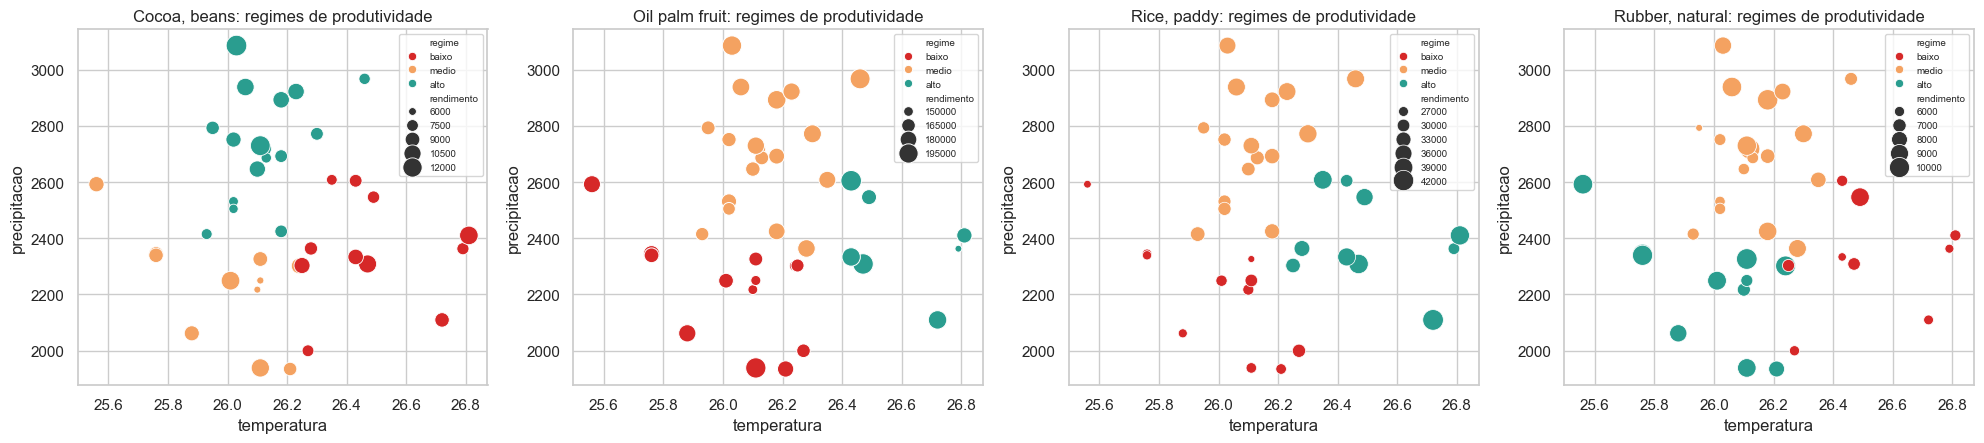

In [16]:
# === Diferença de condições climáticas entre os regimes de rendimento alto e baixo ===
delta = (perfil_regimes.xs("alto", level="regime")[NUMERICAS]        # clima médio no regime alto
         - perfil_regimes.xs("baixo", level="regime")[NUMERICAS])    # menos clima médio no regime baixo
delta.columns = [f"Δ {c} (alto − baixo)" for c in NUMERICAS]        # renomeia para leitura
ganho = (perfil_regimes.xs("alto", level="regime")[ALVO]
         / perfil_regimes.xs("baixo", level="regime")[ALVO] - 1) * 100   # ganho % de rendimento alto vs baixo
delta["ganho de rendimento (%)"] = ganho
display(delta)

fig, axes = plt.subplots(1, len(CULTURAS), figsize=(5 * len(CULTURAS), 4.6))
axes = np.atleast_1d(axes)
for ax, cult in zip(axes, CULTURAS):                                 # um gráfico por cultura
    sub = df[df["cultura"] == cult]
    sns.scatterplot(data=sub, x="temperatura", y="precipitacao", hue="regime", hue_order=NOMES_REGIME,
                    size=ALVO, sizes=(25, 220), palette={"baixo": "#d62828", "medio": "#f4a261", "alto": "#2a9d8f"},
                    legend="brief", ax=ax)
    ax.set_title(f"{cult}: regimes de produtividade")                # cor = regime, tamanho = rendimento
    ax.legend(fontsize=7, loc="best")
plt.tight_layout()
fig.savefig(ASSETS / "regimes_produtividade.png", dpi=120, bbox_inches="tight")
plt.show()

### 4.4 Cenários discrepantes (outliers)

Consolidamos três sinais de anomalia por observação:

- **`out_iqr`** – rendimento fora de `[Q1 − 1,5·IQR; Q3 + 1,5·IQR]` calculado **dentro da cultura** (regra do boxplot);
- **`out_dist`** – distância ao centróide do seu regime maior que média + 2 desvios-padrão (cenário que "não se encaixa" em nenhum grupo);
- **`out_iso`** – apontado como anomalia pelo Isolation Forest treinado na cultura (combinação atípica de clima e rendimento).

Uma observação é tratada como **cenário discrepante** quando é sinalizada por **pelo menos dois** métodos.

In [17]:
# === Outliers univariados (IQR por cultura) e consolidação dos métodos ===
def fora_do_iqr(s, fator=1.5):
    """Retorna True para valores fora de [Q1 - fator*IQR, Q3 + fator*IQR]."""
    q1, q3 = s.quantile(0.25), s.quantile(0.75)                      # quartis
    iqr = q3 - q1                                                    # amplitude interquartil
    return (s < q1 - fator * iqr) | (s > q3 + fator * iqr)           # máscara booleana

df["out_iqr"] = df.groupby("cultura")[ALVO].transform(fora_do_iqr)  # aplica a regra dentro de cada cultura
METODOS = ["out_iqr", "out_dist", "out_iso"]
df["n_metodos"] = df[METODOS].sum(axis=1)                            # em quantos métodos a linha foi sinalizada
df["outlier"] = df["n_metodos"] >= 2                                 # critério final: 2 ou mais métodos

print("Observações sinalizadas por método:")
print(df[METODOS].sum().to_string())
print(f"\nCenários discrepantes (>= 2 métodos): {df['outlier'].sum()} de {len(df)} linhas")

outliers = (df.loc[df["outlier"], ["cultura", "regime"] + NUMERICAS + [ALVO] + METODOS + ["n_metodos"]]
              .sort_values(["cultura", ALVO]))                       # tabela dos cenários discrepantes
display(outliers)

Observações sinalizadas por método:
out_iqr     0
out_dist    9
out_iso     8

Cenários discrepantes (>= 2 métodos): 8 de 156 linhas


,cultura,regime,precipitacao,umidade_especifica,umidade_relativa,temperatura,rendimento,out_iqr,out_dist,out_iso,n_metodos
1,"Cocoa, beans",medio,1938.42,17.54,82.11,26.11,11253,False,True,True,2
27,"Cocoa, beans",alto,3085.79,18.34,86.10,26.03,13056,False,True,True,2
56,Oil palm fruit,alto,2362.80,18.70,84.03,26.79,142425,False,True,True,2
40,Oil palm fruit,baixo,1938.42,17.54,82.11,26.11,201436,False,True,True,2
81,"Rice, paddy",baixo,2592.35,17.61,85.07,25.56,25187,False,True,True,2
79,"Rice, paddy",baixo,1938.42,17.54,82.11,26.11,27619,False,True,True,2
118,"Rubber, natural",alto,1938.42,17.54,82.11,26.11,9223,False,True,True,2
120,"Rubber, natural",alto,2592.35,17.61,85.07,25.56,9718,False,True,True,2


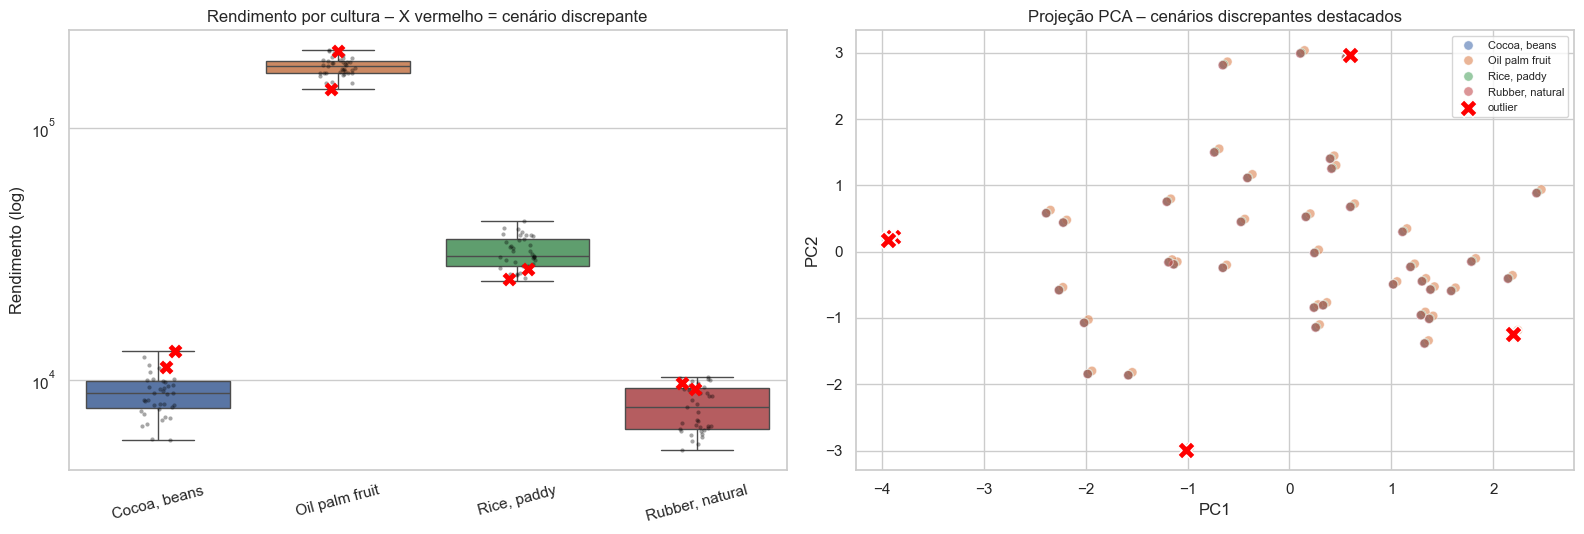

In [18]:
# === Visualização dos cenários discrepantes ===
fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))
sns.boxplot(data=df, x="cultura", y=ALVO, hue="cultura", legend=False, ax=axes[0])        # distribuição por cultura
sns.stripplot(data=df[~df["outlier"]], x="cultura", y=ALVO, color="black", alpha=0.35, size=3, ax=axes[0])
sns.stripplot(data=df[df["outlier"]], x="cultura", y=ALVO, color="red", marker="X", size=10, ax=axes[0])  # outliers em vermelho
axes[0].set_yscale("log"); axes[0].set(title="Rendimento por cultura – X vermelho = cenário discrepante", xlabel="", ylabel="Rendimento (log)")
axes[0].tick_params(axis="x", rotation=15)

sns.scatterplot(data=df[~df["outlier"]], x="pc1", y="pc2", hue="cultura", s=45, alpha=0.6, ax=axes[1])
sns.scatterplot(data=df[df["outlier"]], x="pc1", y="pc2", color="red", marker="X", s=160, label="outlier", ax=axes[1])
axes[1].set(title="Projeção PCA – cenários discrepantes destacados", xlabel="PC1", ylabel="PC2")
axes[1].legend(fontsize=8)
plt.tight_layout()
fig.savefig(ASSETS / "outliers.png", dpi=120, bbox_inches="tight")
plt.show()

### 4.5 Tendência temporal do rendimento (ordem das observações como proxy do ano)

A base não tem coluna de ano, mas há fortes indícios de que as linhas de cada cultura estão em **ordem cronológica**: os 39 perfis climáticos aparecem exatamente na mesma sequência nas quatro culturas e, ao longo dessa sequência, a temperatura sobe de forma consistente (aquecimento observado nas últimas décadas). Usando a posição da observação como proxy do ano, verificamos se o rendimento apresenta tendência ao longo do tempo – informação essencial para interpretar corretamente as associações entre clima e rendimento.

Sequência climática idêntica nas 4 culturas: True
Tendência da temperatura ao longo da sequência: +0.58 ºC no período (r = 0.66); precipitação: r = 0.42


,"r(posição, rendimento)"
cultura,
"Cocoa, beans",0.10
Oil palm fruit,0.50
"Rice, paddy",0.91
"Rubber, natural",-0.36


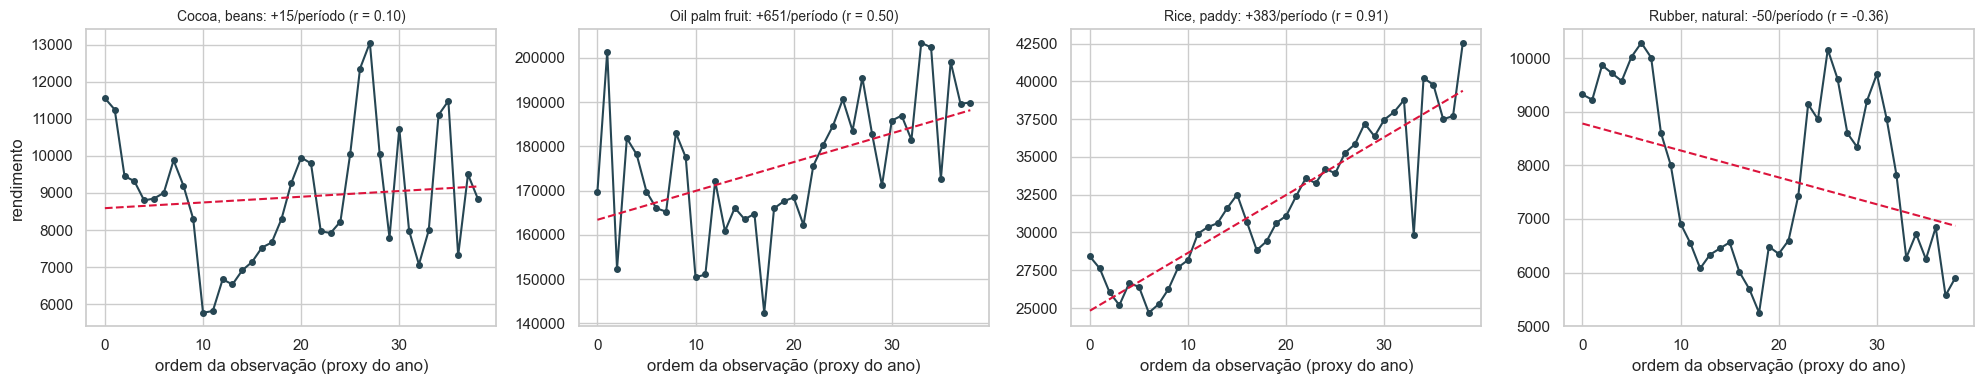

In [19]:
# === Tendência temporal do rendimento (ordem das observações como proxy do ano) ===
df["posicao"] = df.groupby("cultura").cumcount()                      # posição 0..38 dentro de cada cultura
referencia = df.loc[df["cultura"] == CULTURAS[0], NUMERICAS].to_numpy()          # sequência climática da 1ª cultura
mesma_ordem = all(np.array_equal(df.loc[df["cultura"] == c, NUMERICAS].to_numpy(), referencia) for c in CULTURAS)
print(f"Sequência climática idêntica nas {len(CULTURAS)} culturas: {mesma_ordem}")
coef_temp = np.polyfit(df["posicao"], df["temperatura"], 1)[0]        # inclinação da temperatura por período
print(f"Tendência da temperatura ao longo da sequência: {coef_temp * (df['posicao'].max()):+.2f} ºC no período "
      f"(r = {df['posicao'].corr(df['temperatura']):.2f}); precipitação: r = {df['posicao'].corr(df['precipitacao']):.2f}")

corr_pos = (df.groupby("cultura")[["posicao", ALVO]].corr()["posicao"]   # correlação posição x rendimento por cultura
              .unstack()[[ALVO]].rename(columns={ALVO: "r(posição, rendimento)"}))
display(corr_pos)

fig, axes = plt.subplots(1, len(CULTURAS), figsize=(5 * len(CULTURAS), 4))
axes = np.atleast_1d(axes)
for ax, cult in zip(axes, CULTURAS):                                 # uma série por cultura
    sub = df[df["cultura"] == cult]
    ax.plot(sub["posicao"], sub[ALVO], marker="o", ms=4, color="#264653")          # rendimento ao longo da sequência
    coef = np.polyfit(sub["posicao"], sub[ALVO], 1)                                # reta de tendência linear
    ax.plot(sub["posicao"], np.polyval(coef, sub["posicao"]), "--", color="crimson")
    ax.set_title(f"{cult}: {coef[0]:+.0f}/período (r = {sub['posicao'].corr(sub[ALVO]):.2f})", fontsize=10)
    ax.set_xlabel("ordem da observação (proxy do ano)")
    ax.set_ylabel(ALVO if cult == CULTURAS[0] else "")
plt.tight_layout()
fig.savefig(ASSETS / "tendencia_temporal.png", dpi=120, bbox_inches="tight")
plt.show()

### 4.6 Interpretação das tendências e dos outliers

**Clusterização global (K-Means + hierárquica).** A silhueta é baixa para qualquer k (entre 0,32 e 0,39), sinal de que a estrutura de grupos é fraca; o melhor valor (k = 8, silhueta 0,391) separa o **dendê** em três grupos de anos (17, 11 e 11 observações), isolado pelo seu rendimento muito maior, enquanto **cacau, arroz e borracha caem exatamente nos mesmos cinco clusters, com as mesmas contagens (8, 10, 4, 13 e 4)**: como as três têm rendimento "pequeno" na escala global e compartilham o clima, o algoritmo as agrupa pelo **ano climático**, e não pela cultura. As duas primeiras componentes principais explicam 74,8% da variância, e o dendrograma de Ward confirma dois macrogrupos (dendê × demais culturas) subdivididos por perfis climáticos. Lição: na escala global, o único "grupo natural" é a cultura de maior rendimento; para enxergar tendências é preciso olhar dentro de cada cultura.

**Regimes de produtividade por cultura.** As tendências são diferentes – e até opostas – entre culturas:

| Cultura | Regime *alto* em relação ao *baixo* | Ganho de rendimento |
|---------|--------------------------------------|--------------------:|
| Arroz | anos mais quentes (+0,49 ºC), mais úmidos (+0,57 g/kg) e mais chuvosos (+182 mm) | **+32,1%** |
| Borracha | anos mais frescos (−0,53 ºC), mais secos (−0,59 g/kg; −99 mm) | **+37,8%** |
| Dendê | anos mais quentes (+0,56 ºC) e mais úmidos (+0,59 g/kg) | +6,9% |
| Cacau | anos muito mais chuvosos (+374 mm) e com maior umidade relativa (+1,5 p.p.) | +1,5% (praticamente insensível) |

**Tendência temporal.** A sequência climática é idêntica nas quatro culturas e a temperatura sobe ao longo dela (r = 0,66), o que sustenta a hipótese de ordem cronológica. Nesse eixo, o **arroz** apresenta forte tendência de alta (r = 0,91), o **dendê** tendência moderada (r = 0,50), o **cacau** é estável (r = 0,10) e a **borracha** tende a cair (r = −0,36). Isso tem uma implicação importante: como a temperatura também cresce com o tempo, parte da associação "anos mais quentes → mais arroz" pode refletir **ganhos tecnológicos ao longo dos anos** (variedades, manejo, irrigação), e não um efeito climático. A tendência de produtividade mais robusta encontrada na base é, portanto, temporal: arroz e dendê em alta, cacau estável e borracha em queda.

**Cenários discrepantes.** A regra do IQR não sinalizou nenhum rendimento extremo dentro das culturas; os métodos multivariados (distância ao centróide: 9; Isolation Forest: 8) convergiram em **8 observações (duas por cultura)**. Elas não parecem erros de medição, e sim **anos climáticos extremos**: o ano mais seco da série (1.938 mm, também o de menor umidade: 17,54 g/kg e 82,1%) é sinalizado nas quatro culturas – e no dendê produziu um dos maiores rendimentos (201.436); o ano mais frio (25,56 ºC) aparece no arroz (rendimento baixo, 25.187) e na borracha (rendimento alto, 9.718); o ano mais chuvoso (3.086 mm) no cacau (rendimento máximo, 13.056); e o ano mais quente e úmido (26,79 ºC; 18,70 g/kg) no dendê, com o seu **menor** rendimento (142.425). São exatamente os cenários que a fazenda precisa conhecer: eventos climáticos extremos afetam cada cultura de forma diferente. Por serem observações reais e a base ser pequena, esses cenários foram **mantidos** na modelagem; o impacto dessa decisão é medido na seção 5.7.

## 5. Modelagem preditiva com regressão supervisionada

### 5.1 Definição do problema e boas práticas adotadas

- **Alvo (y):** `rendimento`. **Atributos (X):** `cultura` (categórica) + as quatro variáveis climáticas.
- A `cultura` entra como atributo porque a fazenda produz várias culturas e o modelo deve prever o rendimento *da cultura informada*; sem ela, o clima sozinho não distingue produtividades de escalas tão diferentes.
- **Separação treino/teste (80/20)** estratificada por cultura, feita **antes** de qualquer ajuste: o conjunto de teste só é usado na avaliação final.
- **Pré-processamento dentro de um `Pipeline`** (`OneHotEncoder` para a cultura e `StandardScaler` para o clima), evitando vazamento de dados (*data leakage*).
- **Validação cruzada repetida (5 folds × 3 repetições)** no conjunto de treino para comparar os algoritmos de forma robusta em uma base pequena.
- **Ajuste de hiperparâmetros com `GridSearchCV`** e seleção do melhor modelo **pela validação cruzada**, não pelo teste.
- **Baselines** como referência: a média global (`DummyRegressor`) e a média por cultura – qualquer modelo útil precisa superá-las.
- **Métricas:** MAE e RMSE (erro na unidade do rendimento), MAPE (erro percentual, comparável entre culturas) e R² (fração da variância explicada).

### 5.2 Os cinco algoritmos

| # | Algoritmo | Família | Por que foi escolhido |
|---|-----------|---------|-----------------------|
| 1 | Regressão Linear Múltipla | Linear | Modelo interpretável e referência clássica |
| 2 | Árvore de Decisão | Árvore | Captura relações não lineares e interações clima × cultura |
| 3 | Random Forest | Ensemble (bagging) | Reduz a variância da árvore, robusto a outliers |
| 4 | Gradient Boosting | Ensemble (boosting) | Corrige erros sequencialmente; costuma ter alta acurácia em dados tabulares |
| 5 | SVR (kernel RBF) | Máquina de vetores de suporte | Modela não linearidades suaves; alvo padronizado por ser sensível à escala |

In [20]:
# === Separação treino/teste e pré-processamento ===
from sklearn.model_selection import train_test_split, RepeatedKFold, KFold, cross_validate, GridSearchCV
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score, mean_absolute_percentage_error

FEATURES = ["cultura"] + NUMERICAS                                   # atributos de entrada
X = df[FEATURES].copy()                                              # matriz de atributos
y = df[ALVO].copy()                                                  # vetor alvo

X_train, X_test, y_train, y_test = train_test_split(                 # divisão 80/20
    X, y, test_size=0.2, stratify=X["cultura"], random_state=RANDOM_STATE)   # estratificada por cultura
print(f"Treino: {len(X_train)} linhas | Teste: {len(X_test)} linhas")
print("Teste por cultura:", X_test["cultura"].value_counts().to_dict())

preprocessador = ColumnTransformer([                                  # transforma cada tipo de coluna
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), ["cultura"]),  # cultura -> dummies
    ("num", StandardScaler(), NUMERICAS),                            # clima -> média 0, desvio 1
])

def montar_pipeline(modelo):
    """Encadeia o pré-processamento e o modelo em um único estimador."""
    return Pipeline([("prep", preprocessador), ("modelo", modelo)])

def avaliar(y_true, y_pred):
    """Calcula as métricas de regressão usadas no trabalho."""
    return {"MAE": mean_absolute_error(y_true, y_pred),
            "RMSE": root_mean_squared_error(y_true, y_pred),
            "MAPE_%": 100 * mean_absolute_percentage_error(y_true, y_pred),
            "R2": r2_score(y_true, y_pred)}

Treino: 124 linhas | Teste: 32 linhas
Teste por cultura: {'Rice, paddy': 8, 'Oil palm fruit': 8, 'Cocoa, beans': 8, 'Rubber, natural': 8}


In [21]:
# === Baselines e os cinco modelos candidatos ===
baselines = {
    "Baseline: média global": montar_pipeline(DummyRegressor(strategy="mean")),      # prevê sempre a média
    "Baseline: média por cultura": Pipeline([                                         # média de cada cultura
        ("prep", ColumnTransformer([("cat", OneHotEncoder(sparse_output=False), ["cultura"])])),
        ("modelo", LinearRegression())]),
}
modelos = {
    "Regressão Linear":  montar_pipeline(LinearRegression()),
    "Árvore de Decisão": montar_pipeline(DecisionTreeRegressor(random_state=RANDOM_STATE)),
    "Random Forest":     montar_pipeline(RandomForestRegressor(n_estimators=300, random_state=RANDOM_STATE)),
    "Gradient Boosting": montar_pipeline(GradientBoostingRegressor(random_state=RANDOM_STATE)),
    "SVR (RBF)":         montar_pipeline(TransformedTargetRegressor(                  # SVR com alvo padronizado
                              regressor=SVR(kernel="rbf", C=10, epsilon=0.1), transformer=StandardScaler())),
}

### 5.3 Comparação inicial por validação cruzada (hiperparâmetros padrão)

,MAE,RMSE,RMSE_std,R2,R2_std
modelo,,,,,
Gradient Boosting,4300.37,7009.56,1840.26,0.99,0.01
Random Forest,4199.76,7083.56,1875.10,0.99,0.00
Regressão Linear,5256.37,7817.00,1941.35,0.99,0.00
Baseline: média por cultura,5008.92,7858.65,2194.11,0.99,0.00
Árvore de Decisão,4904.81,8171.44,2388.12,0.99,0.01
SVR (RBF),13815.33,19520.42,4768.82,0.92,0.05
Baseline: média global,60941.38,71145.59,7343.18,-0.06,0.04


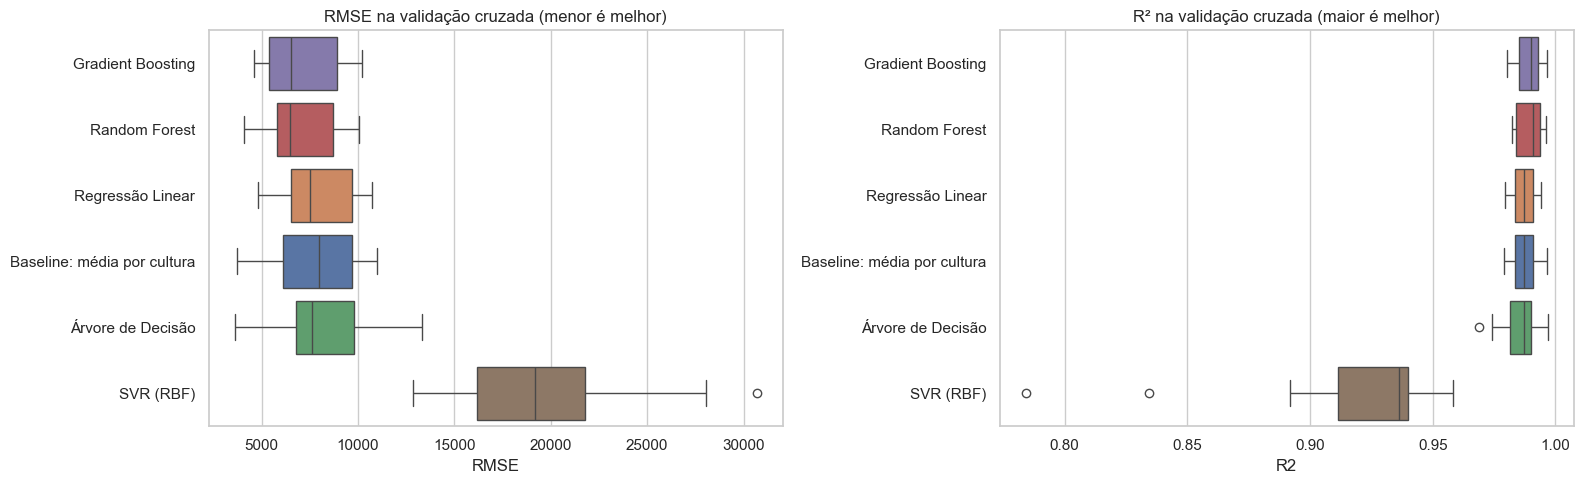

In [22]:
# === Validação cruzada repetida no conjunto de treino ===
cv = RepeatedKFold(n_splits=5, n_repeats=3, random_state=RANDOM_STATE)   # 15 avaliações por modelo
scoring = {"MAE": "neg_mean_absolute_error", "RMSE": "neg_root_mean_squared_error", "R2": "r2"}

linhas, detalhes = [], []                                            # resumo e valores fold a fold
for nome, pipe in {**baselines, **modelos}.items():                  # baselines + 5 modelos
    res = cross_validate(pipe, X_train, y_train, cv=cv, scoring=scoring)   # validação cruzada
    linhas.append({"modelo": nome,
                   "MAE": -res["test_MAE"].mean(), "RMSE": -res["test_RMSE"].mean(),
                   "RMSE_std": res["test_RMSE"].std(), "R2": res["test_R2"].mean(), "R2_std": res["test_R2"].std()})
    detalhes += [{"modelo": nome, "RMSE": -v, "R2": r} for v, r in zip(res["test_RMSE"], res["test_R2"])]

cv_resumo = pd.DataFrame(linhas).set_index("modelo").sort_values("RMSE")   # ordena do menor ao maior erro
display(cv_resumo)

cv_detalhes = pd.DataFrame(detalhes)
cv_detalhes = cv_detalhes[cv_detalhes["modelo"] != "Baseline: média global"]   # escala dominada pela média global
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
ordem = [m for m in cv_resumo.index if m != "Baseline: média global"]
sns.boxplot(data=cv_detalhes, x="RMSE", y="modelo", order=ordem, hue="modelo", legend=False, ax=axes[0])
axes[0].set(title="RMSE na validação cruzada (menor é melhor)", ylabel="")
sns.boxplot(data=cv_detalhes, x="R2", y="modelo", order=ordem, hue="modelo", legend=False, ax=axes[1])
axes[1].set(title="R² na validação cruzada (maior é melhor)", ylabel="")
plt.tight_layout(); plt.show()

### 5.4 Ajuste de hiperparâmetros (GridSearchCV)

A Regressão Linear não possui hiperparâmetros; os outros quatro algoritmos são otimizados por busca em grade com validação cruzada de 5 folds, usando o RMSE como critério.

In [23]:
# === Busca em grade dos hiperparâmetros ===
grades = {                                                           # espaço de busca de cada algoritmo
    "Árvore de Decisão": {"modelo__max_depth": [2, 3, 4, 6, 8, None],
                          "modelo__min_samples_leaf": [1, 2, 4, 8]},
    "Random Forest":     {"modelo__n_estimators": [200, 500],
                          "modelo__max_depth": [None, 4, 8],
                          "modelo__min_samples_leaf": [1, 2, 4],
                          "modelo__max_features": [None, "sqrt"]},
    "Gradient Boosting": {"modelo__n_estimators": [100, 300],
                          "modelo__learning_rate": [0.03, 0.1],
                          "modelo__max_depth": [2, 3],
                          "modelo__subsample": [0.8, 1.0]},
    "SVR (RBF)":         {"modelo__regressor__C": [1, 10, 100],
                          "modelo__regressor__epsilon": [0.05, 0.1, 0.2],
                          "modelo__regressor__gamma": ["scale", 0.1, 0.5]},
}
cv_grid = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)  # folds embaralhados e fixos

modelos_ajustados, melhores_params, rmse_cv = {}, {}, {}             # resultados da busca
for nome, pipe in modelos.items():                                   # percorre os 5 modelos
    if nome in grades:                                               # modelos com grade definida
        busca = GridSearchCV(pipe, grades[nome], cv=cv_grid, scoring="neg_root_mean_squared_error", n_jobs=1)
        busca.fit(X_train, y_train)                                  # executa a busca
        modelos_ajustados[nome] = busca.best_estimator_              # melhor pipeline reajustado no treino
        melhores_params[nome] = {k.replace("modelo__", "").replace("regressor__", ""): v
                                 for k, v in busca.best_params_.items()}
        rmse_cv[nome] = -busca.best_score_                           # RMSE médio da melhor combinação
    else:                                                            # Regressão Linear: sem hiperparâmetros
        res = cross_validate(pipe, X_train, y_train, cv=cv_grid, scoring="neg_root_mean_squared_error")
        modelos_ajustados[nome] = pipe.fit(X_train, y_train)
        melhores_params[nome] = {"(sem hiperparâmetros)": "-"}
        rmse_cv[nome] = -res["test_score"].mean()
    print(f"{nome:18s} | RMSE CV = {rmse_cv[nome]:10.2f} | melhores parâmetros: {melhores_params[nome]}")

Regressão Linear   | RMSE CV =    8007.33 | melhores parâmetros: {'(sem hiperparâmetros)': '-'}


Árvore de Decisão  | RMSE CV =    8458.60 | melhores parâmetros: {'max_depth': 3, 'min_samples_leaf': 8}


Random Forest      | RMSE CV =    7680.80 | melhores parâmetros: {'max_depth': 4, 'max_features': None, 'min_samples_leaf': 1, 'n_estimators': 200}


Gradient Boosting  | RMSE CV =    7312.00 | melhores parâmetros: {'learning_rate': 0.03, 'max_depth': 2, 'n_estimators': 300, 'subsample': 0.8}


SVR (RBF)          | RMSE CV =   15068.00 | melhores parâmetros: {'C': 10, 'epsilon': 0.05, 'gamma': 0.1}


### 5.5 Avaliação final no conjunto de teste

Os modelos ajustados são avaliados **uma única vez** no conjunto de teste, que não participou de nenhuma etapa anterior, juntamente com os baselines.

,RMSE_CV,MAE,RMSE,MAPE_%,R2
modelo,,,,,
Baseline: média por cultura,NaN,4631.23,8023.90,13.48,0.99
Regressão Linear,8007.33,4988.89,8543.63,16.32,0.98
Random Forest,7680.80,4973.86,9680.93,12.67,0.98
SVR (RBF),15068.00,6940.07,9995.24,41.47,0.98
Gradient Boosting,7312.00,5834.45,10324.01,19.21,0.98
Árvore de Decisão,8458.60,5493.83,10628.80,14.19,0.98
Baseline: média global,NaN,58085.01,67525.18,338.41,-0.00


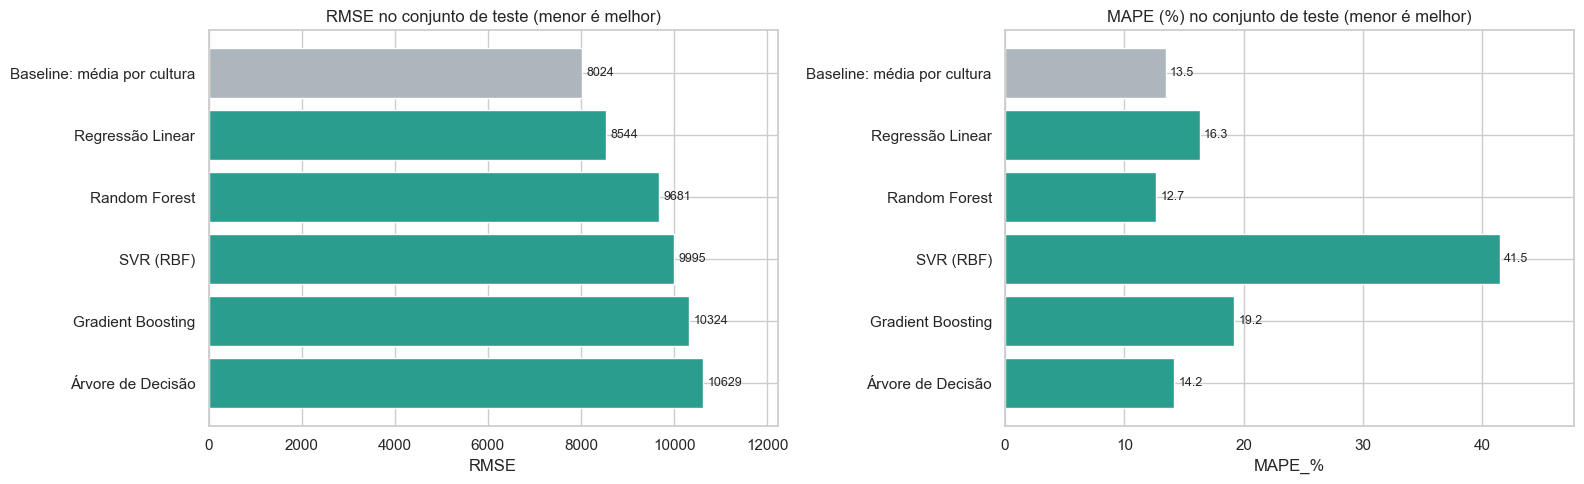

In [24]:
# === Métricas no conjunto de teste ===
for nome, pipe in baselines.items():                                 # ajusta os baselines no treino
    pipe.fit(X_train, y_train)

resultados = []
for nome, pipe in {**baselines, **modelos_ajustados}.items():        # avalia baselines e modelos otimizados
    m = avaliar(y_test, pipe.predict(X_test))                        # métricas no teste
    m["modelo"] = nome
    m["RMSE_CV"] = rmse_cv.get(nome, np.nan)                         # referência da validação cruzada
    resultados.append(m)

tabela_teste = (pd.DataFrame(resultados).set_index("modelo")[["RMSE_CV", "MAE", "RMSE", "MAPE_%", "R2"]]
                  .sort_values("RMSE"))                              # ordena pelo RMSE de teste
display(tabela_teste)

grafico = tabela_teste.drop(index="Baseline: média global")          # a média global (RMSE ~67 mil) esmagaria a escala
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
cores = ["#adb5bd" if "Baseline" in n else "#2a9d8f" for n in grafico.index]   # baseline em cinza
for ax, met, titulo in zip(axes, ["RMSE", "MAPE_%"],
                           ["RMSE no conjunto de teste (menor é melhor)", "MAPE (%) no conjunto de teste (menor é melhor)"]):
    barras = ax.barh(grafico.index, grafico[met], color=cores); ax.invert_yaxis()   # barras horizontais
    ax.bar_label(barras, fmt="%.1f" if met == "MAPE_%" else "%.0f", padding=3, fontsize=9)   # valor ao lado da barra
    ax.set(title=titulo, xlabel=met); ax.set_xlim(right=grafico[met].max() * 1.15)
plt.tight_layout()
fig.savefig(ASSETS / "comparacao_modelos.png", dpi=120, bbox_inches="tight")
plt.show()

### 5.6 Diagnóstico do melhor modelo

O melhor modelo é escolhido pelo **RMSE da validação cruzada** (boa prática: evita "escolher pelo teste"). Analisamos valores reais × previstos, resíduos, desempenho **por cultura** e a importância dos atributos por permutação.

Melhor modelo (por validação cruzada): Gradient Boosting
Métricas no teste: {'MAE': 5834.447, 'RMSE': 10324.013, 'MAPE_%': 19.212, 'R2': 0.977}


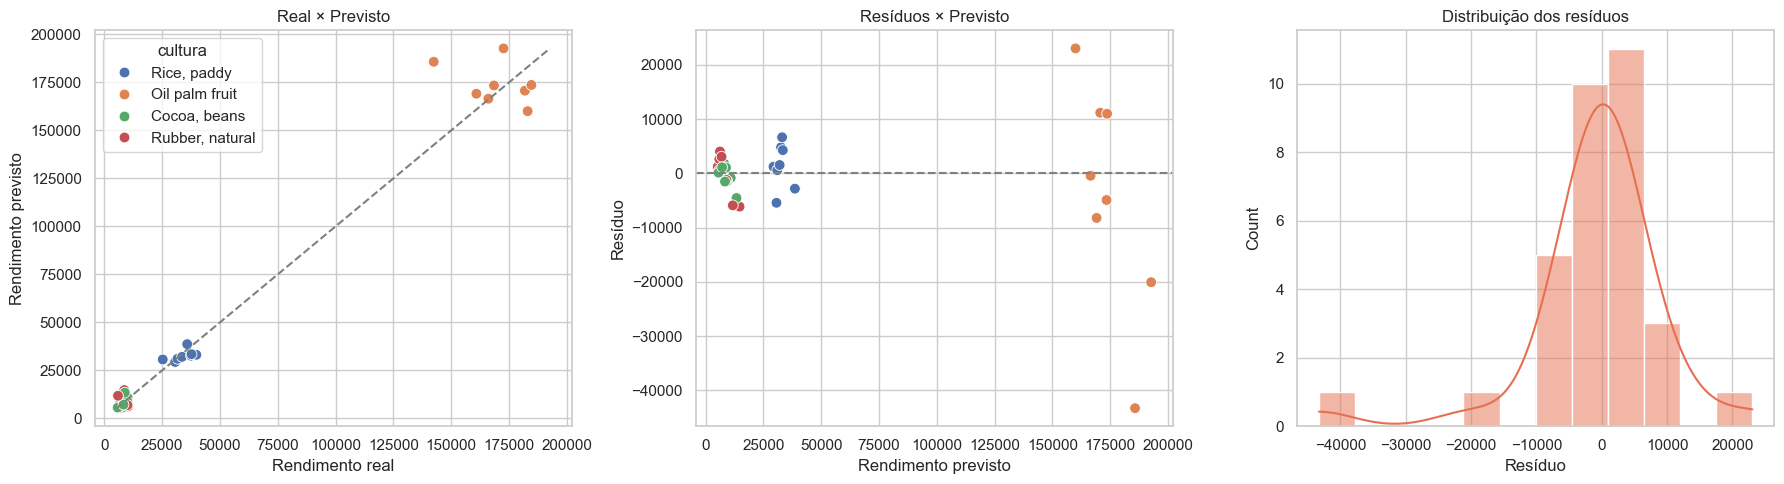

In [25]:
# === Seleção do melhor modelo e diagnóstico ===
from sklearn.inspection import permutation_importance                # importância por permutação

melhor_nome = min(rmse_cv, key=rmse_cv.get)                          # menor RMSE na validação cruzada
melhor = modelos_ajustados[melhor_nome]                              # pipeline correspondente
y_pred = melhor.predict(X_test)                                      # previsões no teste
residuos = y_test - y_pred                                           # erro de cada previsão
print(f"Melhor modelo (por validação cruzada): {melhor_nome}")
print("Métricas no teste:", {k: round(v, 3) for k, v in avaliar(y_test, y_pred).items()})

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.scatterplot(x=y_test, y=y_pred, hue=X_test["cultura"], s=60, ax=axes[0])    # real x previsto
lim = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
axes[0].plot(lim, lim, "--", color="gray"); axes[0].set(title="Real × Previsto", xlabel="Rendimento real", ylabel="Rendimento previsto")
sns.scatterplot(x=y_pred, y=residuos, hue=X_test["cultura"], s=60, ax=axes[1], legend=False)   # resíduos x previsto
axes[1].axhline(0, color="gray", ls="--"); axes[1].set(title="Resíduos × Previsto", xlabel="Rendimento previsto", ylabel="Resíduo")
sns.histplot(residuos, kde=True, ax=axes[2], color="#e76f51"); axes[2].set(title="Distribuição dos resíduos", xlabel="Resíduo")
plt.tight_layout()
fig.savefig(ASSETS / "real_vs_previsto.png", dpi=120, bbox_inches="tight")
plt.show()

Métricas do melhor modelo por cultura (R² calculado dentro da cultura):


,MAE,RMSE,MAPE_%,R2,n_teste
cultura,,,,,
"Cocoa, beans",1555.93,1978.48,18.03,-0.85,8
Oil palm fruit,15262.78,19823.61,9.37,-1.26,8
"Rice, paddy",3421.08,3990.67,10.10,0.18,8
"Rubber, natural",3098.00,3677.71,39.35,-4.82,8


,atributo,aumento_RMSE,std
0,cultura,85053.26,9935.61
1,precipitacao,407.77,866.41
2,umidade_especifica,-212.76,276.20
3,umidade_relativa,-703.44,506.33
4,temperatura,-1324.21,605.49


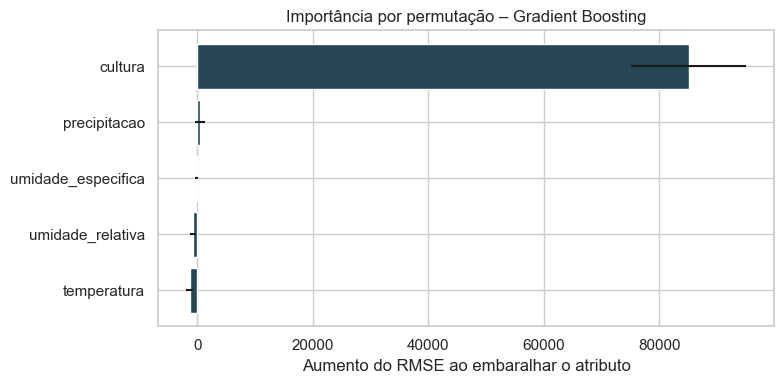

In [26]:
# === Desempenho por cultura e importância dos atributos ===
avaliacao_cultura = (pd.DataFrame({"cultura": X_test["cultura"].values, "real": y_test.values, "prev": y_pred})
                       .groupby("cultura")
                       .apply(lambda g: pd.Series(avaliar(g["real"], g["prev"])), include_groups=False))
avaliacao_cultura["n_teste"] = X_test["cultura"].value_counts()      # tamanho do teste em cada cultura
print("Métricas do melhor modelo por cultura (R² calculado dentro da cultura):")
display(avaliacao_cultura)

perm = permutation_importance(melhor, X_test, y_test, n_repeats=30,   # embaralha cada atributo 30 vezes
                              scoring="neg_root_mean_squared_error", random_state=RANDOM_STATE)
importancia = (pd.DataFrame({"atributo": FEATURES, "aumento_RMSE": perm.importances_mean, "std": perm.importances_std})
                 .sort_values("aumento_RMSE", ascending=False))      # quanto o erro cresce ao embaralhar o atributo
display(importancia)

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(importancia["atributo"], importancia["aumento_RMSE"], xerr=importancia["std"], color="#264653")
ax.invert_yaxis(); ax.set(title=f"Importância por permutação – {melhor_nome}", xlabel="Aumento do RMSE ao embaralhar o atributo")
plt.tight_layout(); plt.show()

### 5.7 Sensibilidade aos cenários discrepantes

Os outliers identificados na seção 4 foram **mantidos** no treinamento, pois são observações reais e a base é pequena. Para medir o impacto dessa decisão, reajustamos o melhor modelo sem os cenários discrepantes do treino e comparamos as métricas no mesmo conjunto de teste.

In [27]:
# === Reajuste sem outliers no treino e comparação ===
from sklearn.base import clone                                       # cópia do pipeline com os mesmos hiperparâmetros

mascara = ~df.loc[X_train.index, "outlier"]                          # linhas do treino que NÃO são outliers
modelo_sem_out = clone(melhor).fit(X_train[mascara], y_train[mascara])   # reajusta só com dados "limpos"
comparacao = pd.DataFrame({
    "com outliers no treino": avaliar(y_test, melhor.predict(X_test)),
    "sem outliers no treino": avaliar(y_test, modelo_sem_out.predict(X_test)),
}).T
print(f"Linhas removidas do treino: {(~mascara).sum()}")
comparacao

Linhas removidas do treino: 7


,MAE,RMSE,MAPE_%,R2
com outliers no treino,5834.45,10324.01,19.21,0.98
sem outliers no treino,5972.72,10863.14,19.57,0.97


### 5.8 Modelo final e exemplo de uso

O modelo final é reajustado com **todos os dados** (treino + teste) usando os hiperparâmetros encontrados e salvo em disco (`modelo_rendimento_safra.joblib`). Esse é o artefato que seria hospedado na API em nuvem discutida na Entrega 2: a API recebe as leituras dos sensores (precipitação, umidades e temperatura) e a cultura, e devolve o rendimento previsto. Abaixo, uma simulação de cenários com o clima mediano de cada cultura e uma variação de +1 ºC.

In [28]:
# === Modelo final, persistência e simulação de cenários ===
import joblib                                                        # serialização do modelo

modelo_final = clone(melhor).fit(X, y)                               # reajusta com toda a base
joblib.dump({"modelo": modelo_final, "features": FEATURES, "algoritmo": melhor_nome}, "modelo_rendimento_safra.joblib")
print(f"Modelo final ({melhor_nome}) salvo em modelo_rendimento_safra.joblib")

cenarios = df.groupby("cultura")[NUMERICAS].median().reset_index()   # clima mediano observado em cada cultura
cenarios["rendimento_previsto"] = modelo_final.predict(cenarios[FEATURES])          # previsão no clima mediano
mais_quente = cenarios.copy(); mais_quente["temperatura"] += 1.0                      # cenário +1 ºC
cenarios["previsto_com_+1ºC"] = modelo_final.predict(mais_quente[FEATURES])
cenarios["variação_%"] = 100 * (cenarios["previsto_com_+1ºC"] / cenarios["rendimento_previsto"] - 1)
cenarios

Modelo final (Gradient Boosting) salvo em modelo_rendimento_safra.joblib


,cultura,precipitacao,umidade_especifica,umidade_relativa,temperatura,rendimento_previsto,previsto_com_+1ºC,variação_%
0,"Cocoa, beans",2424.55,18.27,84.85,26.13,9071.76,9551.81,5.29
1,Oil palm fruit,2424.55,18.27,84.85,26.13,170748.53,172534.38,1.05
2,"Rice, paddy",2424.55,18.27,84.85,26.13,31871.27,33218.71,4.23
3,"Rubber, natural",2424.55,18.27,84.85,26.13,8475.99,8758.25,3.33


### 5.9 Extra: e se a tendência temporal entrasse como atributo?

Os cinco modelos acima usam apenas cultura e clima, como pede o enunciado. Como a seção 4.5 mostrou uma tendência temporal forte (sobretudo no arroz), testamos – a título de diagnóstico, com o mesmo split – o que acontece quando a posição na sequência (proxy do ano) é adicionada aos atributos.

In [29]:
# === Extra: tendência temporal como atributo (mesmo split de treino/teste) ===
FEATURES_T = FEATURES + ["posicao"]                                  # atributos originais + proxy do ano
prep_t = ColumnTransformer([                                         # pré-processamento com a nova coluna numérica
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), ["cultura"]),
    ("num", StandardScaler(), NUMERICAS + ["posicao"])])
Xt_train, Xt_test = df.loc[X_train.index, FEATURES_T], df.loc[X_test.index, FEATURES_T]   # mesmos índices do split

candidatos_t = {"Regressão Linear + tendência": LinearRegression(),
                f"{melhor_nome} + tendência": clone(melhor.named_steps["modelo"])}       # mesmos hiperparâmetros
extra = {f"{melhor_nome} (cultura + clima)": avaliar(y_test, melhor.predict(X_test))}   # referência: sem tendência
for nome, mod in candidatos_t.items():                               # ajusta e avalia cada candidato
    pipe_t = Pipeline([("prep", prep_t), ("modelo", mod)]).fit(Xt_train, y_train)
    pred_t = pipe_t.predict(Xt_test)
    extra[nome] = avaliar(y_test, pred_t)
mape_cult_t = (pd.DataFrame({"cultura": X_test["cultura"].values, "real": y_test.values, "prev": pred_t})
                 .groupby("cultura").apply(lambda g: 100 * mean_absolute_percentage_error(g["real"], g["prev"]), include_groups=False))
print(f"MAPE por cultura – {list(candidatos_t)[-1]}:", mape_cult_t.round(1).to_dict())
pd.DataFrame(extra).T

MAPE por cultura – Gradient Boosting + tendência:

 {'Cocoa, beans': 22.0, 'Oil palm fruit': 6.9, 'Rice, paddy': 7.9, 'Rubber, natural': 40.4}


,MAE,RMSE,MAPE_%,R2
Gradient Boosting (cultura + clima),5834.45,10324.01,19.21,0.98
Regressão Linear + tendência,5036.91,7352.70,25.91,0.99
Gradient Boosting + tendência,4782.51,7813.08,19.30,0.99


Com a tendência temporal, o Gradient Boosting reduz o RMSE de teste de 10.324 para 7.813 (−24%) e o MAE de 5.834 para 4.783, com R² 0,99; no arroz, o MAPE cai de 10,1% para 7,9% e, no dendê, de 9,4% para 6,9% – justamente as culturas com tendência temporal mais forte. Cacau e borracha continuam difíceis (MAPE de 22% e 40%), pois neles nem o clima nem o tempo explicam bem a variação. O resultado sustenta a principal recomendação do trabalho: para prever o rendimento na fazenda, é mais valioso registrar **quando** e **como** cada safra foi conduzida do que refinar o algoritmo. Este experimento é diagnóstico e não substitui os cinco modelos oficiais, que seguem a especificação do enunciado (previsão a partir das condições climáticas).

## 6. Conclusões, pontos fortes e limitações

### 6.1 Principais achados

1. **A cultura explica quase tudo; o clima, pouco.** Todos os cinco modelos alcançam R² ≈ 0,98 no conjunto de teste, mas o baseline "média por cultura" chega a R² 0,99, RMSE 8.024 e MAPE 13,5% – ou seja, o R² alto vem da identidade da cultura (rendimentos que diferem em até 20 vezes), não do clima. A importância por permutação confirma: embaralhar a cultura aumenta o RMSE em ≈ 85.000, enquanto embaralhar qualquer variável climática não piora o erro. Dentro de cada cultura, o R² do melhor modelo é ≤ 0,18: o clima anual, com a pouca variação que apresenta nesta região equatorial, explica uma fração pequena da oscilação de rendimento entre anos.
2. **Ranking dos modelos.** Pela validação cruzada (critério de seleção), o melhor foi o **Gradient Boosting** (RMSE CV 7.312; no teste: MAE 5.834, RMSE 10.324, MAPE 19,2%, R² 0,977), seguido de Random Forest (7.681), Regressão Linear (8.007), Árvore de Decisão (8.459) e SVR (15.068). No teste, a Regressão Linear obteve o menor erro entre os cinco (RMSE 8.544; MAPE 16,3%), mas as diferenças entre os quatro melhores estão dentro do ruído da validação cruzada (desvio-padrão de 1.800 a 2.400 no RMSE) e o conjunto de teste tem apenas 32 linhas. O SVR foi o mais fraco: com poucos dados e alvo em escalas muito distintas, o kernel RBF não capturou bem o "degrau" entre culturas.
3. **Erro por cultura.** O melhor modelo erra em média 9,4% no dendê, 10,1% no arroz, 18,0% no cacau e 39,4% na borracha (MAPE). Em termos práticos, a previsão para as duas culturas de maior valor é utilizável; para cacau e borracha, o modelo entrega pouco além da média histórica.
4. **Tendências de produtividade.** Os regimes de produtividade mostraram efeitos climáticos distintos por cultura – arroz e dendê rendem mais em anos mais quentes e úmidos; borracha, em anos mais frescos e secos; cacau é insensível. A tendência mais robusta, porém, é **temporal**: arroz (r = 0,91) e dendê (r = 0,50) em alta ao longo da série, cacau estável e borracha em queda (r = −0,36). O teste extra da seção 5.9 mostra o valor dessa informação: adicioná-la ao Gradient Boosting reduz o RMSE de teste em 24% (de 10.324 para 7.813) e o MAPE do arroz de 10,1% para 7,9%.
5. **Cenários discrepantes.** Oito observações (duas por cultura) foram sinalizadas por dois métodos; correspondem aos anos climáticos extremos da série (mais seco, mais frio, mais chuvoso e mais quente/úmido), com efeitos opostos entre culturas. Mantê-las no treino foi a decisão correta: removê-las piorou ligeiramente o erro no teste (RMSE 10.863 contra 10.324).
6. **Sensibilidade a +1 ºC.** Com o clima mediano, o modelo final projeta variação de +1,1% (dendê) a +5,3% (cacau) no rendimento para +1 ºC – uma tendência aprendida da série histórica, a ser lida com cautela dada a baixa importância do clima e a possível confusão com a tendência temporal.

### 6.2 Pontos fortes do trabalho

- Boas práticas de ML aplicadas de ponta a ponta: separação treino/teste estratificada **antes** de qualquer ajuste, pré-processamento dentro de `Pipeline` (sem vazamento), validação cruzada repetida, busca de hiperparâmetros com `GridSearchCV`, seleção do modelo pela validação (não pelo teste) e avaliação final única.
- Baselines explícitos, que evitaram a leitura ingênua do "R² = 0,98", e métricas complementares (MAE, RMSE, MAPE, R²), inclusive **por cultura**.
- Análise não supervisionada em dois níveis (global e por cultura), três métodos de detecção de outliers com consolidação por consenso e um teste de sensibilidade que quantifica o impacto dos outliers.
- Interpretabilidade: importância por permutação, análise de resíduos, correlações dentro das culturas e identificação da tendência temporal e das unidades reais dos dados.
- Reprodutibilidade: semente fixa, código comentado, figuras salvas e modelo final serializado, pronto para a API da Entrega 2.

### 6.3 Limitações

- **Base pequena e pouco variada:** 39 anos × 4 culturas de uma única região; o conjunto de teste tem 32 linhas, o que torna as métricas instáveis e impede afirmar com segurança qual dos quatro melhores algoritmos é superior.
- **Clima idêntico entre culturas e de baixa variabilidade** (0,26 ºC de desvio-padrão na temperatura), o que limita estruturalmente o poder preditivo das variáveis climáticas.
- **Ausência de variáveis relevantes:** o enunciado menciona condições de solo, mas a base não traz solo, manejo, adubação, irrigação, área plantada, pragas ou preços – fatores que dominam a variação de rendimento entre anos.
- **Sem coluna de ano:** a tendência temporal foi inferida pela ordem das observações (hipótese bem sustentada, mas ainda uma hipótese), e a associação clima × rendimento no arroz pode estar confundida com ganhos tecnológicos ao longo do tempo.
- **Unidade do rendimento inferida** (hg/ha) e dados aparentemente de outra região/país, o que exige cautela ao transferir o modelo para a fazenda brasileira de 200 ha.
- **Escala absoluta do alvo:** MAE e RMSE são dominados pelo dendê; a comparação entre culturas depende do MAPE.

### 6.4 Próximos passos

- Coletar dados da própria fazenda com os sensores previstos na Entrega 2 (solo, umidade, temperatura por talhão) e registrar ano, área e manejo.
- Incluir a dimensão temporal de forma explícita (ano, defasagens climáticas mensais na estação de crescimento) e validar com divisão temporal (`TimeSeriesSplit`), em vez de aleatória.
- Modelar o rendimento relativo (log ou desvio em relação à tendência da cultura) e produzir intervalos de predição (por exemplo, Gradient Boosting com perda quantílica).
- Monitorar o modelo em produção (drift dos dados dos sensores) e re-treinar periodicamente.

## 7. Referências

- FIAP. *Modelagem de Dados com Regressão Supervisionada* (Fase 4, Cap. 13) e *Machine Learning Sem Supervisão: Uma Jornada pela Descoberta de Dados* (Fase 5, Cap. 10).
- Base de dados `crop_yield.csv` disponibilizada no portal da disciplina.
- PEDREGOSA, F. et al. *Scikit-learn: Machine Learning in Python*. JMLR 12, 2011 – documentação em https://scikit-learn.org/stable/.
- WASKOM, M. *seaborn: statistical data visualization*. JOSS 6(60), 2021.
- CHAPMAN, P. et al. *CRISP-DM 1.0: Step-by-step data mining guide*. 2000.